In [1]:
# If running on a fresh environment, you may need to install:
# pip install numpy scipy scikit-learn matplotlib mdtraj mdanalysis tqdm seaborn


# Notes:
# - Notebook uses mdtraj if present, else MDAnalysis. mdtraj keeps units in nm.
# - If MD trajectory dt is not discoverable, code assumes dt=1.0 time unit for MD-derived calculations

In [2]:
# Cell 2 — Imports & setup
import os
import math
import logging
from functools import partial
import numpy as np
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import cm
from scipy.spatial.distance import cdist
from scipy.linalg import expm
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.neighbors import NearestNeighbors
import hdbscan


# Try mdtraj then MDAnalysis
try:
    import mdtraj as md
    backend = 'mdtraj'
except Exception:
    md = None
    try:
        import MDAnalysis as mda
        backend = 'mda'
    except Exception:
        mda = None
        backend = None

logging.basicConfig(level=logging.INFO)
logger = logging.getLogger('ctmc_nb')


# plotting defaults
sns.set(style='whitegrid')
np.set_printoptions(precision=4, suppress=True)


rng = np.random.default_rng()


def sample_categorical(probs, rng_local=None):
    if rng_local is None:
        rng_local = rng
    probs = np.asarray(probs, dtype=float)
    tot = probs.sum()
    if tot <= 0:
        return int(rng_local.integers(0, probs.shape[0]))
    return int(rng_local.choice(len(probs), p=(probs / tot)))

print('backend =', backend)

backend = mdtraj


In [3]:
# Cell 3 — PARAMETERS (edit these paths/options)
PARAMS = {
    'mc_traj_path': 'hmc_traj-fit.dcd',
    'mc_topology': 'pentane-org.pdb',
    'md_traj_path': 'fit-short-trajectory-80.pdb',
    'md_topology': 'pentane-org.pdb',

    'use_dihedrals': True,
    'n_pca': 2,
    'cluster_algorithm': 'hdbscan',  # 'kmeans' or 'hdbscan'
    'n_clusters': 7,
    'k_neighbors': 6,
    'adjacency_mode': 'combined',  # 'delaunay', 'transitions', 'combined', 'union'

    'neighbor_median_weight': 0.1,
    'initial_k0': 1.0,

    # 'gaussian'      : centroid-distance Gaussian kernel (original)
    # 'barrier_height': KDE FES + minimax Dijkstra saddle-point kernel (Kramers)
    'kernel_type': 'barrier_height',

    # scale_method: 'none', 'mfpt', 'md'
    'scale_method': 'md',
    'md_scale_by': 'slowest_mode',  # 'max_exit' or 'frobenius or slowest_exit or slowest_mode'

    'mfpt_macro_choice': 'largest_to_farthest',

    'T_final': 1000.0,
    'initial_cluster': None,

    'outputs_dir': 'pentane_ctmc_outputs',
    'sim_runs': 50,
    'max_models': 5000,
    'sim_random_start': False,
    'sim_view_index': 0,
    # directory containing multiple MD trajectories (optional)
    'md_dir': 'pentane-md',  # e.g. 'events_inputs'
}

os.makedirs(PARAMS['outputs_dir'], exist_ok=True)

for key in ['mc_traj_path', 'mc_topology', 'md_traj_path', 'md_topology']:
    if not os.path.exists(PARAMS[key]):
        logger.warning(f"File {{PARAMS[key]}} not found. Please set PARAMS['{key}'] to your path.")

PARAMS['n_clusters'] = int(PARAMS['n_clusters'])

In [4]:
# Cell 4 — Helper functions: IO & featurization
def load_trajectory(traj_path, top_path=None):
    if backend == 'mdtraj':
        return md.load(traj_path, top=top_path)
    elif backend == 'mda':
        return mda.Universe(top_path, traj_path)
    else:
        raise RuntimeError('No trajectory backend available. Install mdtraj or MDAnalysis.')


def infer_dt(traj_obj):
    if backend == 'mdtraj' and isinstance(traj_obj, md.Trajectory):
        return float(getattr(traj_obj, 'timestep', None)) if getattr(traj_obj, 'timestep', None) is not None else None
    elif backend == 'mda' and isinstance(traj_obj, mda.Universe):
        try:
            return float(traj_obj.trajectory.dt)
        except Exception:
            return None
    return None

def find_dihedral_quads(topology):
    neigh = {a.index: set() for a in topology.atoms}
    for bond in topology.bonds:
        i = bond[0].index; j = bond[1].index
        neigh[i].add(j); neigh[j].add(i)
    quads = []
    for bond in topology.bonds:
        b = bond[0].index; c = bond[1].index
        for a in neigh[b]:
            if a == c: continue
            for d in neigh[c]:
                if d == b: continue
                quads.append([a,b,c,d])
    uniq = []
    seen = set()
    for q in quads:
        t = tuple(q)
        if t not in seen:
            seen.add(t); uniq.append(t)
    return np.array(uniq, dtype=int)

def compute_features(traj_obj, use_dihedrals=True):

    if backend == 'mdtraj' and isinstance(traj_obj, md.Trajectory) and use_dihedrals:
        try:
            dihedral_indices = find_dihedral_quads(traj_obj.topology)
            ######################################### debug
            dihedral_indices = np.array([[0,1,2,3],[1,2,3,4]])
            ######################################### debug
            if dihedral_indices.shape[0] > 0:
                dihedrals = md.compute_dihedrals(traj_obj, dihedral_indices)
                feats = np.concatenate([np.sin(dihedrals), np.cos(dihedrals)], axis=1)
                return feats
        except Exception as e:
            logger.info(f'generic dihedral extraction failed: {e}')

print('Helper functions loaded')

Helper functions loaded


In [5]:
# Cell 5 — Load MC frames and MD short traj (if available) and compute features
mc_traj = None
md_traj = None
feats_mc = None
feats_md = None
labels_md = None

try:
    mc_traj = load_trajectory(PARAMS['mc_traj_path'], PARAMS['mc_topology'])
    logger.info('Loaded MC trajectory')
except Exception as e:
    logger.warning(f'Could not load MC trajectory: {{e}}')

try:
    md_traj = load_trajectory(PARAMS['md_traj_path'], PARAMS['md_topology'])
    logger.info('Loaded MD trajectory')
except Exception as e:
    logger.warning(f'Could not load MD trajectory: {{e}}')

if mc_traj is not None:
    feats_mc = compute_features(mc_traj, use_dihedrals=PARAMS['use_dihedrals'])
    logger.info(f'Computed MC features shape: {{feats_mc.shape}}')
else:
    raise RuntimeError('No MC features computed. Cannot continue.')

if md_traj is not None:
    try:
        feats_md = compute_features(md_traj, use_dihedrals=PARAMS['use_dihedrals'])
        logger.info(f'Computed MD features shape: {{feats_md.shape}}')
    except Exception as e:
        logger.warning(f'Could not compute MD features: {{e}}')
        feats_md = None

# Raw dihedral angles in radians — needed by the barrier-height kernel for FES estimation.
# These are the same indices used in compute_features (chi=[0,1,2,3], eta=[1,2,3,4]).
dihedrals_raw_mc = None
if mc_traj is not None and PARAMS['use_dihedrals']:
    _raw_indices = np.array([[0, 1, 2, 3], [1, 2, 3, 4]])
    dihedrals_raw_mc = md.compute_dihedrals(mc_traj, _raw_indices)  # (n_frames, 2), radians
    logger.info(f'Computed raw MC dihedral angles shape: {{dihedrals_raw_mc.shape}}')

# infer dt (if available)
dt_md = infer_dt(md_traj) if md_traj is not None else None
#################### debug
dt_md = 0.16 ## set to 0.16 ps for pentane example
#################### debug
if dt_md is None:
    # fallback default for MD dt
    dt_md = 1.0
    logger.info('MD dt not inferred; using dt_md = 1.0')

logger.info(f'Inferred MD dt = {{dt_md}}')
print('Loaded and featurized')

INFO:ctmc_nb:Loaded MC trajectory
INFO:ctmc_nb:Loaded MD trajectory
INFO:ctmc_nb:Computed MC features shape: {feats_mc.shape}
INFO:ctmc_nb:Computed MD features shape: {feats_md.shape}
INFO:ctmc_nb:Computed raw MC dihedral angles shape: {dihedrals_raw_mc.shape}
INFO:ctmc_nb:Inferred MD dt = {dt_md}


Loaded and featurized


Number of noise frames (label -1) = 524
HDBSCAN found 7 clusters
Cluster counts = [ 7751   464  7598   652  6465 71556  5516]
Cluster populations (pi) = [0.0775 0.0046 0.076  0.0065 0.0646 0.7155 0.0552]


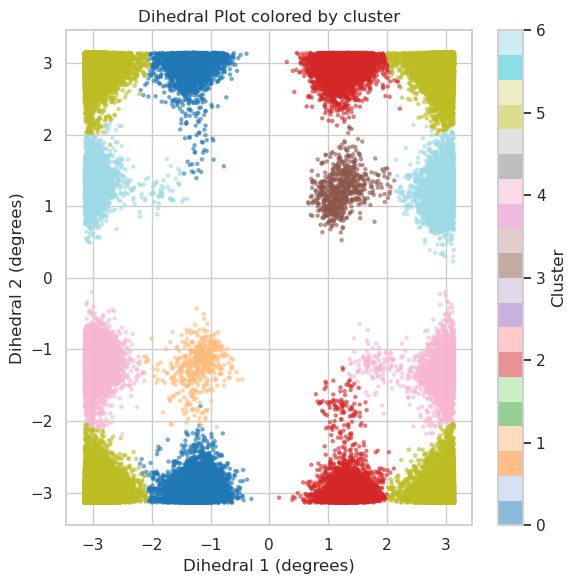

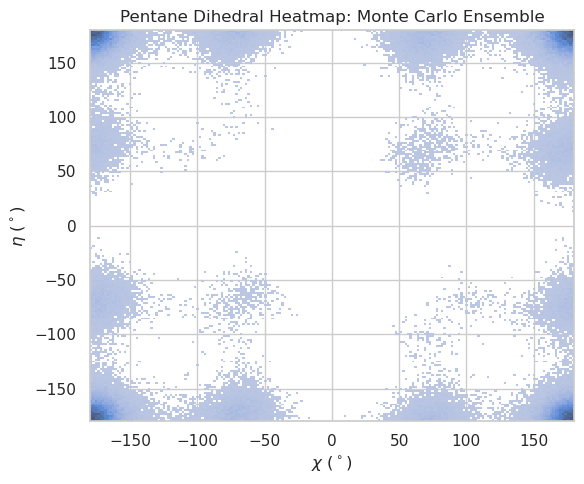

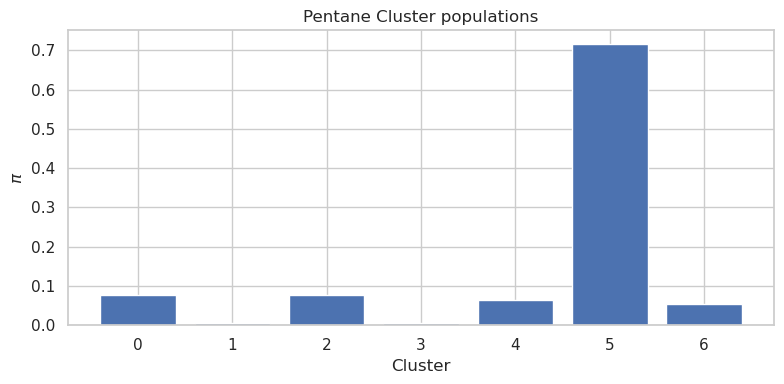

INFO:ctmc_nb:Clusters min/max counts = 464/71556
INFO:ctmc_nb:Initial cluster set to 5


In [6]:
# Cell 6 — Clustering + visualization (PCA embedding, Ramachandran, populations)

if PARAMS['cluster_algorithm'] == 'kmeans':
    N = PARAMS['n_clusters']
    logger.info(f'Clustering into N={N} clusters')
    km = KMeans(n_clusters=N, random_state=42, n_init=20)
    labels = km.fit_predict(feats_mc)
    print(f'Cluster labels for MC frames - 0: {np.sum(labels==0)}, 1: {np.sum(labels==1)}, 2: {np.sum(labels==2)}')
    centroids = km.cluster_centers_
    counts = np.bincount(labels, minlength=N)
    print(f'Cluster counts = {counts}')
    pi = counts / counts.sum()
    print(f'Cluster populations (pi) = {pi}')
else:
###################### HDBSCAN clustering
    N = PARAMS['n_clusters']
    clusterer = hdbscan.HDBSCAN(min_cluster_size=200, min_samples=50)
    labels = clusterer.fit_predict(feats_mc)
    # -1 labels are "noise" — assign to nearest cluster after
    n_found = len(set(labels)) - (1 if -1 in labels else 0)
    print(f'Number of noise frames (label -1) = {(labels == -1).sum()}')
    print(f'HDBSCAN found {n_found} clusters')

    # reassign noise points to nearest cluster centroid
    if (labels == -1).sum() > 0 and n_found > 0:
        noise_indices = np.where(labels == -1)[0]
        if n_found > 0:
            centroids = np.array([clusterer.weighted_cluster_centroid(i) for i in range(n_found)])
            d_noise_to_cent = cdist(feats_mc[noise_indices], centroids)
            nearest_clusters = np.argmin(d_noise_to_cent, axis=1)
            labels[noise_indices] = nearest_clusters

    # get centroids of found clusters
    # centroids = np.array([feats_mc[labels_hdb == i].mean(axis=0) for i in range(n_found)])
    centroids = np.array([clusterer.weighted_cluster_centroid(i) for i in range(n_found)])
    counts = np.bincount(labels, minlength=N)
    print(f'Cluster counts = {counts}')
    pi = counts / counts.sum()
    print(f'Cluster populations (pi) = {pi}')
###################### HDBSCAN clustering


# assign MD frames to clusters (if feats_md available)
labels_md = None
if feats_md is not None:
    d_md_to_cent = cdist(feats_md, centroids)
    labels_md = np.argmin(d_md_to_cent, axis=1)

# Ramachandran plot if possible
if backend == 'mdtraj' and isinstance(mc_traj, md.Trajectory) and PARAMS['use_dihedrals']:
    try:
        phi_idx, phi_vals = md.compute_phi(mc_traj)
        psi_idx, psi_vals = md.compute_psi(mc_traj)
        thetas = np.hstack([phi_vals, psi_vals])
        if thetas.size > 0:
            plt.figure(figsize=(6,6))
            scatter = plt.scatter(np.degrees(thetas[:,0]), np.degrees(thetas[:,1]), c=labels, s=5, cmap='tab20', alpha=0.5)
            plt.xlabel('Phi (degrees)'); plt.ylabel('Psi (degrees)')
            plt.title('Ramachandran Plot colored by cluster')
            plt.xlim([-180,180]); plt.ylim([-180,180])
            plt.colorbar(scatter, label='Cluster')
            plt.tight_layout(); plt.show()
        else:
            # plot the available features in 2D colored by cluster
            dihedral_indices = find_dihedral_quads(mc_traj.topology)
            ######################################### debug
            dihedral_indices = np.array([[0,1,2,3],[1,2,3,4]])
            ######################################### debug
            if dihedral_indices.shape[0] > 0:
                dihedrals = md.compute_dihedrals(mc_traj, dihedral_indices)
                plt.figure(figsize=(6,6))
                scatter = plt.scatter(dihedrals[:,0], dihedrals[:,1], c=labels, s=5, cmap='tab20', alpha=0.5)
                plt.xlabel('Dihedral 1 (degrees)'); plt.ylabel('Dihedral 2 (degrees)')
                plt.title('Dihedral Plot colored by cluster')
                plt.colorbar(scatter, label='Cluster')
                plt.tight_layout(); plt.show()
    except Exception as e:
        logger.info(f'Could not plot Ramachandran with clusters: {e}')

# Heatmap of cluster assignments for MC frames in phi/psi space (if dihedrals available)
if backend == 'mdtraj' and isinstance(mc_traj, md.Trajectory) and PARAMS['use_dihedrals']:
    try:
        dihedral_indices = find_dihedral_quads(mc_traj.topology)
        ######################################### debug
        dihedral_indices = np.array([[0,1,2,3],[1,2,3,4]])
        ######################################### debug
        if dihedral_indices.shape[0] > 0:
            dihedrals = md.compute_dihedrals(mc_traj, dihedral_indices)
            plt.figure(figsize=(6,5))
            sns.histplot(x=np.degrees(dihedrals[:,0]), y=np.degrees(dihedrals[:,1]), bins=200, alpha=1.0)
            plt.xlabel('$\chi$ ($^\circ$)'); plt.ylabel('$\eta$ ($^\circ$)')
            plt.title('Pentane Dihedral Heatmap: Monte Carlo Ensemble')
            plt.xlim([-180,180]); plt.ylim([-180,180])
            plt.tight_layout(); plt.show()
    except Exception as e:
        logger.info(f'Could not plot dihedral histogram: {e}')

# populations bar chart
order = np.argsort(pi)[::-1]
plt.figure(figsize=(8,4))
plt.bar(np.arange(N), pi[:])
plt.xlabel('Cluster'); plt.ylabel('$\pi$')
plt.title('Pentane Cluster populations')
plt.tight_layout(); plt.show()

logger.info(f'Clusters min/max counts = {counts.min()}/{counts.max()}')

if PARAMS['initial_cluster'] is None:
    initial_cluster = int(np.argmax(pi))
else:
    initial_cluster = int(PARAMS['initial_cluster'])
logger.info(f'Initial cluster set to {initial_cluster}')

INFO:ctmc_nb:Adjacency mode: combined
INFO:ctmc_nb:All states have at least one neighbor in adjacency_mask



Adjacency edges (combined):
  0 <-> 1  (transitions: 34)
  0 <-> 2  (transitions: 1)
  0 <-> 4  (transitions: 1)
  0 <-> 5  (transitions: 302)
  0 <-> 6  (transitions: 8)
  1 <-> 4  (transitions: 32)
  2 <-> 3  (transitions: 31)
  2 <-> 4  (transitions: 31)
  2 <-> 5  (transitions: 316)
  2 <-> 6  (transitions: 1)
  3 <-> 6  (transitions: 36)
  4 <-> 5  (transitions: 292)
  4 <-> 6  (transitions: 8)
  5 <-> 6  (transitions: 277)


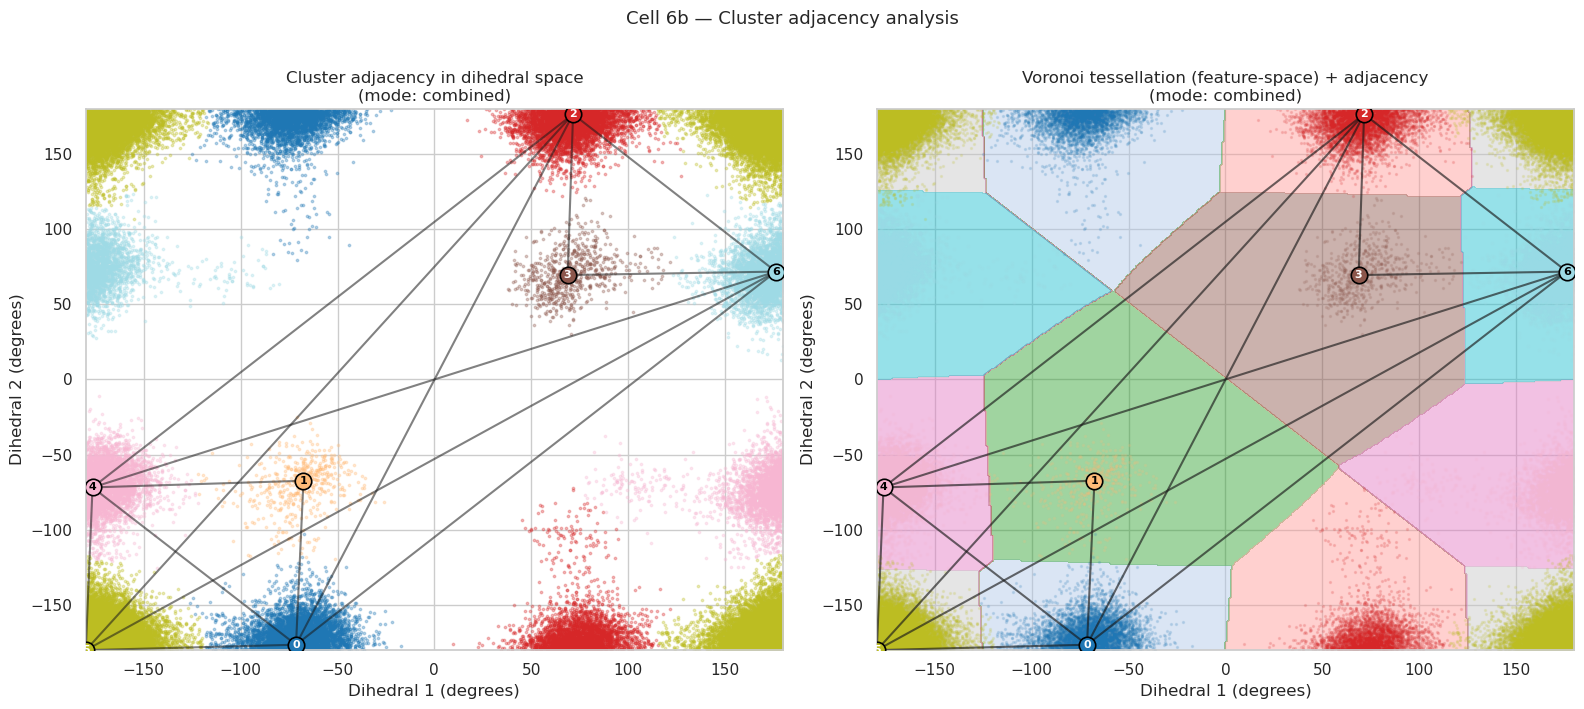

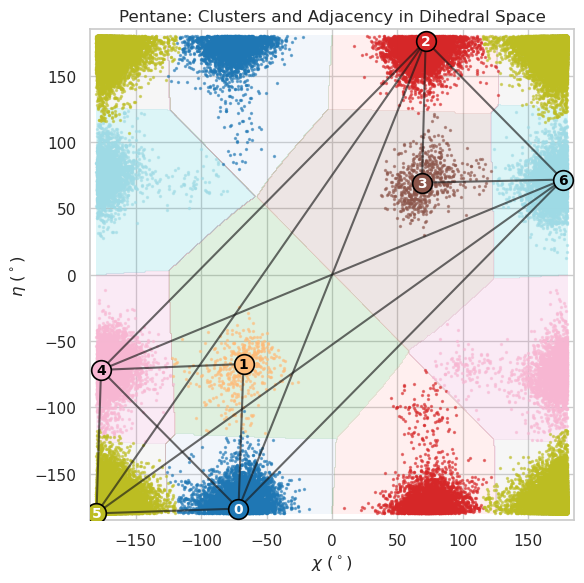

INFO:ctmc_nb:adjacency_mask built — 14 edges total


In [7]:
# %%
# Cell 6b — Cluster adjacency (Delaunay + transitions), dihedral-space visualization

from scipy.spatial import Delaunay

# ── PARAMS flag (add to PARAMS dict if desired) ──────────────────────────────
# 'delaunay'    : geometric adjacency only (centroids)
# 'transitions' : observed transitions only (time-ordered frames)
# 'combined'    : intersection of both (conservative, default)
# 'union'       : union of both (liberal)
ADJACENCY_MODE = PARAMS.get('adjacency_mode', 'combined')

# ── 1. Delaunay adjacency on centroids (in full feature space) ───────────────
tri = Delaunay(centroids)

delaunay_adj = np.zeros((N, N), dtype=bool)
for simplex in tri.simplices:
    for i in range(len(simplex)):
        for j in range(i + 1, len(simplex)):
            a, b = simplex[i], simplex[j]
            delaunay_adj[a, b] = True
            delaunay_adj[b, a] = True

# ── 2. Transition adjacency (time-ordered MC frames) ────────────────────────
transition_adj    = np.zeros((N, N), dtype=bool)
transition_counts = np.zeros((N, N), dtype=int)

for t in range(len(labels) - 1):
    a, b = int(labels[t]), int(labels[t + 1])
    if a != b:
        transition_adj[a, b] = True
        transition_adj[b, a] = True
        transition_counts[a, b] += 1
        transition_counts[b, a] += 1

# ── 3. Build adjacency_mask from chosen mode ─────────────────────────────────
if ADJACENCY_MODE == 'delaunay':
    adjacency_mask = delaunay_adj.copy()
elif ADJACENCY_MODE == 'transitions':
    adjacency_mask = transition_adj.copy()
elif ADJACENCY_MODE == 'union':
    adjacency_mask = delaunay_adj | transition_adj
else:  # 'combined' — default
    adjacency_mask = delaunay_adj & transition_adj

logger.info(f'Adjacency mode: {ADJACENCY_MODE}')

# warn about isolated states
isolated = [i for i in range(N) if not adjacency_mask[i].any()]
if isolated:
    logger.warning(f'States with ZERO neighbors under adjacency_mask: {isolated}')
else:
    logger.info('All states have at least one neighbor in adjacency_mask')

# print edge list
print(f'\nAdjacency edges ({ADJACENCY_MODE}):')
for i in range(N):
    for j in range(i + 1, N):
        if adjacency_mask[i, j]:
            print(f'  {i} <-> {j}  (transitions: {transition_counts[i,j]})')

# ── 4. Recover raw dihedral angles for plotting ──────────────────────────────
# features = [sin(d1), sin(d2), cos(d1), cos(d2)]  shape (n_frames, 4)
# reconstruct angles from sin/cos
_dihedral_indices = np.array([[0, 1, 2, 3], [1, 2, 3, 4]])  # mirrors debug block in Cell 4
_dihedrals_raw    = md.compute_dihedrals(mc_traj, _dihedral_indices)  # (n_frames, 2), radians
phi1_all = np.degrees(_dihedrals_raw[:, 0])
phi2_all = np.degrees(_dihedrals_raw[:, 1])

# centroid positions in dihedral space
# centroids are in sin/cos space; convert back via atan2
centroid_phi1 = np.degrees(np.arctan2(centroids[:, 0], centroids[:, 2]))  # atan2(sin, cos)
centroid_phi2 = np.degrees(np.arctan2(centroids[:, 1], centroids[:, 3]))

# ── 5. Voronoi tessellation on a 2D dihedral grid ───────────────────────────
# We project a dense grid into dihedral space and assign each grid point to
# its nearest centroid (in the original 4D sin/cos feature space) — this is
# the exact same Voronoi as used downstream for cluster assignment.
_grid_res  = 400
_phi1_grid = np.linspace(-180, 180, _grid_res)
_phi2_grid = np.linspace(-180, 180, _grid_res)
_g1, _g2   = np.meshgrid(_phi1_grid, _phi2_grid)
_g1f       = _g1.ravel()
_g2f       = _g2.ravel()

# convert grid points to sin/cos features (same as training features)
_grid_feats = np.column_stack([
    np.sin(np.radians(_g1f)),
    np.sin(np.radians(_g2f)),
    np.cos(np.radians(_g1f)),
    np.cos(np.radians(_g2f)),
])
_grid_dists   = cdist(_grid_feats, centroids)
_grid_labels  = np.argmin(_grid_dists, axis=1).reshape(_grid_res, _grid_res)

# ── 6. Plots ─────────────────────────────────────────────────────────────────
cmap_pts  = plt.get_cmap('tab20')
clr       = [cmap_pts(k / max(N - 1, 1)) for k in range(N)]

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# ── Panel A: scatter + adjacency graph in dihedral space ─────────────────────
ax = axes[0]
for k in range(N):
    mask_k = labels == k
    ax.scatter(phi1_all[mask_k], phi2_all[mask_k],
               s=3, alpha=0.3, color=clr[k], rasterized=True)

# draw adjacency edges between centroids
for i in range(N):
    for j in range(i + 1, N):
        if adjacency_mask[i, j]:
            ax.plot([centroid_phi1[i], centroid_phi1[j]],
                    [centroid_phi2[i], centroid_phi2[j]],
                    'k-', lw=1.5, alpha=0.55, zorder=3)

# centroid markers
for k in range(N):
    ax.scatter(centroid_phi1[k], centroid_phi2[k],
               s=140, color=clr[k], edgecolors='black', linewidths=1.2, zorder=5)
    ax.annotate(str(k), (centroid_phi1[k], centroid_phi2[k]),
                fontsize=8, ha='center', va='center',
                fontweight='bold', zorder=6,
                color='white' if np.mean(clr[k][:3]) < 0.6 else 'black')

ax.set_xlim([-180, 180]); ax.set_ylim([-180, 180])
ax.set_xlabel('Dihedral 1 (degrees)'); ax.set_ylabel('Dihedral 2 (degrees)')
ax.set_title(f'Cluster adjacency in dihedral space\n(mode: {ADJACENCY_MODE})')

# ── Panel B: Voronoi tessellation + adjacency graph ──────────────────────────
ax = axes[1]
ax.contourf(_g1, _g2, _grid_labels,
            levels=np.arange(-0.5, N + 0.5, 1),
            cmap='tab20', alpha=0.45)

# overlay data points lightly
for k in range(N):
    mask_k = labels == k
    ax.scatter(phi1_all[mask_k], phi2_all[mask_k],
               s=2, alpha=0.15, color=clr[k], rasterized=True)

# adjacency edges
for i in range(N):
    for j in range(i + 1, N):
        if adjacency_mask[i, j]:
            ax.plot([centroid_phi1[i], centroid_phi1[j]],
                    [centroid_phi2[i], centroid_phi2[j]],
                    'k-', lw=1.5, alpha=0.65, zorder=3)

# centroids
for k in range(N):
    ax.scatter(centroid_phi1[k], centroid_phi2[k],
               s=140, color=clr[k], edgecolors='black', linewidths=1.2, zorder=5)
    ax.annotate(str(k), (centroid_phi1[k], centroid_phi2[k]),
                fontsize=8, ha='center', va='center',
                fontweight='bold', zorder=6,
                color='white' if np.mean(clr[k][:3]) < 0.6 else 'black')

ax.set_xlim([-180, 180]); ax.set_ylim([-180, 180])
ax.set_xlabel('Dihedral 1 (degrees)'); ax.set_ylabel('Dihedral 2 (degrees)')
ax.set_title(f'Voronoi tessellation (feature-space) + adjacency\n(mode: {ADJACENCY_MODE})')

plt.suptitle('Cell 6b — Cluster adjacency analysis', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()


# paper-ready version with only the Voronoi panel, well labeled and cropped
fig, ax = plt.subplots(figsize=(6, 6))
ax.contourf(_g1, _g2, _grid_labels,
            levels=np.arange(-0.5, N + 0.5, 1),
            cmap='tab20', alpha=0.15)
for k in range(N):
    mask_k = labels == k
    ax.scatter(phi1_all[mask_k], phi2_all[mask_k],
               s=2, alpha=0.55, color=clr[k], rasterized=True)
for i in range(N):
    for j in range(i + 1, N):
        if adjacency_mask[i, j]:
            ax.plot([centroid_phi1[i], centroid_phi1[j]],
                    [centroid_phi2[i], centroid_phi2[j]],
                    'k-', lw=1.5, alpha=0.65, zorder=3)
for k in range(N):
    ax.scatter(centroid_phi1[k], centroid_phi2[k],
               s=200, color=clr[k], edgecolors='black', linewidths=1.2, zorder=5)
    ax.annotate(str(k), (centroid_phi1[k], centroid_phi2[k]),
                fontsize=10, ha='center', va='center',
                fontweight='bold', zorder=6,
                color='white' if np.mean(clr[k][:3]) < 0.6 else 'black')
ax.set_xlim([-185, 185]); ax.set_ylim([-185, 185])
# ax.set_xlabel('$C_1-C_4$ Dihedral ($^\circ$)'); ax.set_ylabel('$C_2-C_5$ Dihedral ($^\circ$)')
ax.set_xlabel('$\chi$ ($^\circ$)'); ax.set_ylabel('$\eta$ ($^\circ$)')
ax.set_title(f'Pentane: Clusters and Adjacency in Dihedral Space')
plt.tight_layout()
plt.savefig(os.path.join(PARAMS['outputs_dir'], f'cluster_adjacency_{ADJACENCY_MODE}.png'), dpi=300)
plt.show()

logger.info(f'adjacency_mask built — {adjacency_mask.sum()//2} edges total')

INFO:ctmc_nb:Cell 7: using adjacency_mask from Cell 6b ({adj.sum()//2} edges)
INFO:ctmc_nb:s_ij computed via barrier-height kernel (direct watershed saddles on KDE FES)


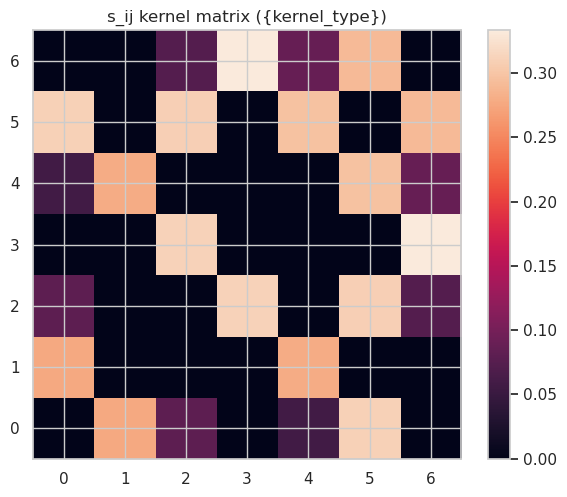

In [8]:
# Cell 7 — Build k-NN graph, s_ij (Gaussian or barrier-height kernel) and visualize

# ── Helper: barrier-height s_ij ──────────────────────────────────────────────
def compute_barrier_s_matrix(feats_raw, labels, centroids_raw, adjacency_mask,
                              N, pi, kT=0.596, grid_bins=200, k0=1.0,
                              periodic=False, x_range=None, y_range=None):
    """
    Compute symmetric weight matrix s_ij via the barrier-height kernel.
    Uses a watershed flood on a KDE-estimated 2D FES to find the direct
    saddle-point free energy F†_ij between each connected pair of states (the
    lowest ridge separating their basins on a path that avoids any third basin).
    s_ij = k0 * exp(-F†_ij / kT) / sqrt(pi_i * pi_j)  (symmetric)
    The saddle is referenced to the reactant well (Kramers/TST), so that
    K_ij = s_ij * sqrt(pi_j/pi_i) = k0 * exp(-F†_ij / kT) / pi_i, i.e. the
    activation barrier is measured from the initial free-energy minimum.

    Parameters
    ----------
    feats_raw : np.ndarray, shape (n_frames, 2)
        Raw 2D MC coordinates (e.g. dihedral angles in radians).
    labels : np.ndarray, shape (n_frames,)
        Cluster label for each MC frame.
    centroids_raw : np.ndarray, shape (N, 2)
        Centroid coordinates in the same 2D raw space.
    adjacency_mask : np.ndarray, shape (N, N), dtype bool
    N : int; kT : float (kcal/mol, 0.596 at 300 K)
    grid_bins : int; k0 : float (pre-exponential scale)

    Returns
    -------
    s : np.ndarray (N, N), symmetric
    F_norm, x_grid, y_grid : FES grid for plotting
    """
    from fes_utils import estimate_fes_2d, coord_to_grid_idx, compute_direct_saddles

    if x_range is None:
        x_range = (feats_raw[:, 0].min() - 0.1, feats_raw[:, 0].max() + 0.1)
    if y_range is None:
        y_range = (feats_raw[:, 1].min() - 0.1, feats_raw[:, 1].max() + 0.1)

    F_norm, x_grid, y_grid = estimate_fes_2d(
        feats_raw, kT=kT, grid_bins=grid_bins,
        x_range=x_range, y_range=y_range, periodic=periodic,
    )

    centroid_grid_idx = []
    for k in range(N):
        i_idx = coord_to_grid_idx(centroids_raw[k, 0], x_range, grid_bins)
        j_idx = coord_to_grid_idx(centroids_raw[k, 1], y_range, grid_bins)
        centroid_grid_idx.append((i_idx, j_idx))

    # Direct saddle network: lowest ridge between each pair of basins on a path
    # that does NOT cross a third basin (watershed flood). Pairs with no shared
    # ridge get np.inf -> no direct transition.
    Fsad = compute_direct_saddles(F_norm, centroid_grid_idx, periodic=periodic)

    s = np.zeros((N, N), dtype=float)
    for i in range(N):
        for j in range(i + 1, N):
            if adjacency_mask[i, j] and np.isfinite(Fsad[i, j]):
                s_val = k0 * np.exp(-Fsad[i, j] / kT) / np.sqrt((pi[i] + 1e-16) * (pi[j] + 1e-16))
                s[i, j] = s_val
                s[j, i] = s_val

    return s, F_norm, x_grid, y_grid


# ── k-NN graph (used by Gaussian kernel; kept for reference in both modes) ───
k = int(PARAMS['k_neighbors'])
nbrs = NearestNeighbors(n_neighbors=min(k+1, N), algorithm='auto').fit(centroids)
distances, indices = nbrs.kneighbors(centroids)
kNN_dists = distances[:,1:] if distances.shape[1]>1 else np.zeros((N,0))
kNN_idx = indices[:,1:] if indices.shape[1]>1 else np.zeros((N,0), dtype=int)

adj = adjacency_mask.copy()
logger.info(f'Cell 7: using adjacency_mask from Cell 6b ({{adj.sum()//2}} edges)')

# ── s_ij dispatch ─────────────────────────────────────────────────────────────
kernel_type = PARAMS.get('kernel_type', 'gaussian')
k0 = float(PARAMS['initial_k0'])
F_norm = x_grid = y_grid = centroids_raw = None  # populated below if barrier_height

if kernel_type == 'gaussian':
    if kNN_dists.size == 0:
        d0 = 0.0
    else:
        d0 = np.median(kNN_dists)
    w0 = float(PARAMS['neighbor_median_weight'])
    if d0 <= 0:
        logger.warning('Median nearest-neighbor distance is zero; setting lambda=1.0')
        lam = 1.0
    else:
        lam = -np.log(w0) / (d0**2)

    s = np.zeros((N, N), dtype=float)
    for i in range(N):
        for j in np.where(adj[i])[0]:
            s[i, j] = k0 * math.exp(-lam * (np.linalg.norm(centroids[i] - centroids[j])**2))
    s = 0.5 * (s + s.T)
    logger.info('s_ij computed via Gaussian kernel')

elif kernel_type == 'barrier_height':
    if dihedrals_raw_mc is None:
        raise RuntimeError("dihedrals_raw_mc is None — ensure use_dihedrals=True in PARAMS.")
    # centroids in raw dihedral angle space (radians), recovered via circular mean
    # features layout: [sin(chi), sin(eta), cos(chi), cos(eta)]
    centroids_raw = np.column_stack([
        np.arctan2(centroids[:, 0], centroids[:, 2]),  # chi
        np.arctan2(centroids[:, 1], centroids[:, 3]),  # eta
    ])
    s, F_norm, x_grid, y_grid = compute_barrier_s_matrix(
        dihedrals_raw_mc, labels, centroids_raw, adjacency_mask,
        N=N, pi=pi, kT=0.596, grid_bins=200, k0=k0,
        periodic=True,
        x_range=(-np.pi, np.pi),
        y_range=(-np.pi, np.pi),
    )
    logger.info('s_ij computed via barrier-height kernel (direct watershed saddles on KDE FES)')

else:
    raise ValueError(f"Unknown kernel_type: {{kernel_type!r}}. Use 'gaussian' or 'barrier_height'.")

plt.figure(figsize=(6,5))
plt.imshow(s, origin='lower')
plt.title(f's_ij kernel matrix ({{kernel_type}})')
plt.colorbar(); plt.tight_layout(); plt.show()

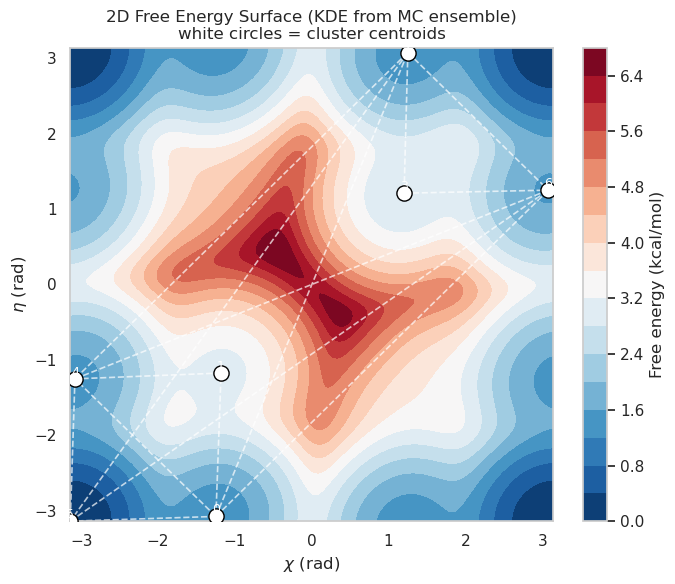

F_norm range: [0.000, 6.772] kcal/mol
s_ij nonzero pairs: 12


In [9]:
# Cell 7b — FES visualization (barrier_height kernel only)
if PARAMS.get('kernel_type', 'gaussian') == 'barrier_height':
    fig, ax = plt.subplots(figsize=(7, 6))
    cf = ax.contourf(x_grid, y_grid, F_norm.T, levels=20, cmap='RdBu_r')
    plt.colorbar(cf, ax=ax, label='Free energy (kcal/mol)')
    ax.scatter(centroids_raw[:, 0], centroids_raw[:, 1],
               c='white', edgecolors='black', s=120, zorder=5, label='Centroids')
    for k_idx in range(N):
        ax.annotate(str(k_idx), centroids_raw[k_idx],
                    color='white', fontsize=9, ha='center', va='bottom', zorder=6)
    # draw adjacency edges with saddle energy annotations
    from fes_utils import coord_to_grid_idx, find_saddle_energy
    x_range = (dihedrals_raw_mc[:, 0].min() - 0.1, dihedrals_raw_mc[:, 0].max() + 0.1)
    y_range = (dihedrals_raw_mc[:, 1].min() - 0.1, dihedrals_raw_mc[:, 1].max() + 0.1)
    for i in range(N):
        for j in range(i + 1, N):
            if adjacency_mask[i, j]:
                ax.plot([centroids_raw[i, 0], centroids_raw[j, 0]],
                        [centroids_raw[i, 1], centroids_raw[j, 1]],
                        'w--', lw=1.2, alpha=0.7)
    ax.set_xlabel(r'$\chi$ (rad)'); ax.set_ylabel(r'$\eta$ (rad)')
    ax.set_title('2D Free Energy Surface (KDE from MC ensemble)\nwhite circles = cluster centroids')
    plt.tight_layout(); plt.show()
    print(f'F_norm range: [{F_norm.min():.3f}, {F_norm.max():.3f}] kcal/mol')
    print(f's_ij nonzero pairs: {(s > 0).sum() // 2}')
else:
    print(f'FES visualization skipped (kernel_type = {{PARAMS["kernel_type"]!r}}).')

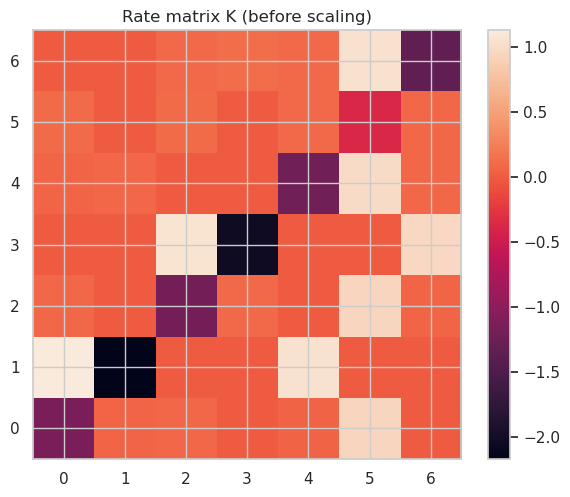

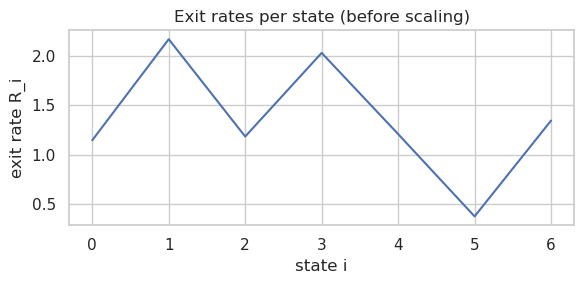

INFO:ctmc_nb:State 0: exit rate R_i = 1.1448
INFO:ctmc_nb:State 1: exit rate R_i = 2.1697
INFO:ctmc_nb:State 2: exit rate R_i = 1.1829
INFO:ctmc_nb:State 3: exit rate R_i = 2.0306
INFO:ctmc_nb:State 4: exit rate R_i = 1.2078
INFO:ctmc_nb:State 5: exit rate R_i = 0.3729
INFO:ctmc_nb:State 6: exit rate R_i = 1.3444


In [10]:
# Cell 8 — Construct K with detailed balance and inspect
K = np.zeros((N,N), dtype=float)
for i in range(N):
    for j in range(N):
        if i!=j and s[i,j] > 0:
            K[i,j] = s[i,j] * math.sqrt((pi[j]+1e-16)/(pi[i]+1e-16))
for i in range(N):
    K[i,i] = -K[i].sum()

plt.figure(figsize=(6,5))
plt.imshow(K, origin='lower')
plt.title('Rate matrix K (before scaling)')
plt.colorbar(); plt.tight_layout(); plt.show()

# exit rates
R = -np.diag(K)
plt.figure(figsize=(6,3))
plt.plot(R)
plt.xlabel('state i'); plt.ylabel('exit rate R_i')
plt.title('Exit rates per state (before scaling)')
plt.tight_layout(); plt.show()

for i in range(N):
    logger.info(f'State {i}: exit rate R_i = {R[i]:.4f}')

INFO:ctmc_nb:MFPT calibration: A=5 (largest-pop), B=2 (farthest)
INFO:ctmc_nb:Model MFPT A->B (before scaling) = 10.688641801882415
INFO:ctmc_nb:Empirical MFPT A->B from MD = 93.89377049180327 (dt=0.16)


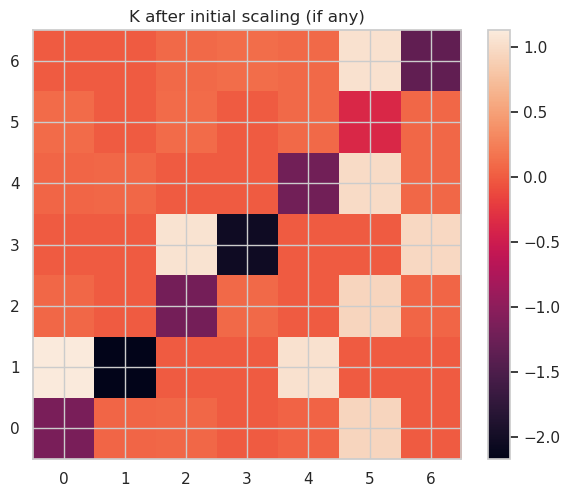

In [11]:
# Cell 9 — MFPT computation and estimation from MD

def mfpt_to_target_from_generator(Kmat, target_idx):
    Nn = Kmat.shape[0]
    transient = [i for i in range(Nn) if i != target_idx]
    K_RR = Kmat[np.ix_(transient, transient)]
    b = np.ones(len(transient))
    try:
        t_sol = np.linalg.solve(-K_RR, b)
    except np.linalg.LinAlgError:
        t_sol = np.linalg.solve(-K_RR - 1e-12*np.eye(K_RR.shape[0]), b)
    t_all = np.zeros(Nn)
    for ii, si in enumerate(transient):
        t_all[si] = t_sol[ii]
    t_all[target_idx] = 0.0
    return t_all

# choose A,B for MFPT
if isinstance(PARAMS['mfpt_macro_choice'], tuple):
    A_idx, B_idx = PARAMS['mfpt_macro_choice']
else:
    A_idx = int(np.argmax(pi))
    dists_from_A = np.linalg.norm(centroids - centroids[A_idx], axis=1)
    B_idx = int(np.argmax(dists_from_A))
    B_idx = 2 # hardcoded for statistical stability in pentane example

logger.info(f'MFPT calibration: A={A_idx} (largest-pop), B={B_idx} (farthest)')

# model MFPT
t_model_to_B = mfpt_to_target_from_generator(K, B_idx)
mfpt_model_A_to_B = t_model_to_B[A_idx]
logger.info(f'Model MFPT A->B (before scaling) = {mfpt_model_A_to_B}')

# empirical MFPT from MD

def compute_empirical_mfpt_from_md(labels_md, A_idx, B_idx, dt=None):
    if labels_md is None:
        return None
    n = len(labels_md)
    hits = []
    i = 0
    while i < n:
        if labels_md[i] == A_idx:
            j = i+1
            while j < n:
                if labels_md[j] == B_idx:
                    delta_frames = j - i
                    time = delta_frames * (dt if dt is not None else 1.0)
                    hits.append(time)
                    break
                j += 1
            while i < n and labels_md[i] == A_idx:
                i += 1
        else:
            i += 1
    if len(hits) == 0:
        logger.warning('No A->B transitions observed in MD for MFPT estimation')
        return None
    return float(np.mean(hits)), np.array(hits)

mfpt_md_res = compute_empirical_mfpt_from_md(labels_md, A_idx, B_idx, dt=dt_md)
if mfpt_md_res is None:
    logger.warning('Could not compute empirical MFPT from MD; calibration option may be skipped.')
    mfpt_md_mean = None
else:
    mfpt_md_mean, hit_times = mfpt_md_res
    logger.info(f'Empirical MFPT A->B from MD = {mfpt_md_mean} (dt={dt_md})')

# scaling options
K_scaled = K.copy()
if PARAMS['scale_method'] == 'mfpt' and mfpt_md_mean is not None and mfpt_model_A_to_B > 0:
    scale_c = mfpt_model_A_to_B / mfpt_md_mean
    logger.info(f'Scaling factor c = {scale_c} (will set K := K * c)')
    K_scaled = K * scale_c
elif PARAMS['scale_method'] == 'md':
    # we will compute K_md below and then apply MD-based scaling
    pass
else:
    logger.info('Skipping scaling; using K as-is')

plt.figure(figsize=(6,5))
plt.imshow(K_scaled, origin='lower')
plt.title('K after initial scaling (if any)')
plt.colorbar(); plt.tight_layout(); plt.show()

INFO:ctmc_nb:Estimated K_md from MD labels


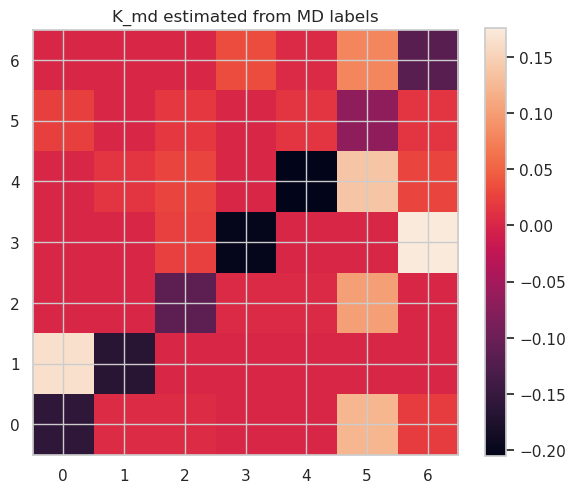

INFO:ctmc_nb:Slow-mode scaling: c=0.08133, tau_model=0.95, tau_md=11.68


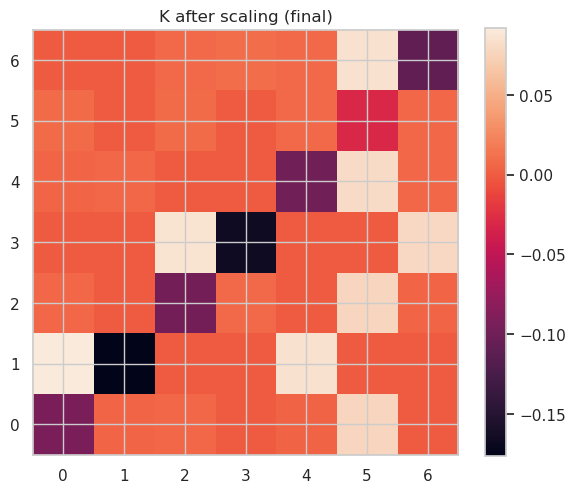

INFO:ctmc_nb:Model MFPT A->B (after scaling) = 131.4303402116988



MFPT comparison (A->B):
  MD empirical MFPT  : 93.894
  Model (before)     : 10.689
  Model (after scale): 131.43


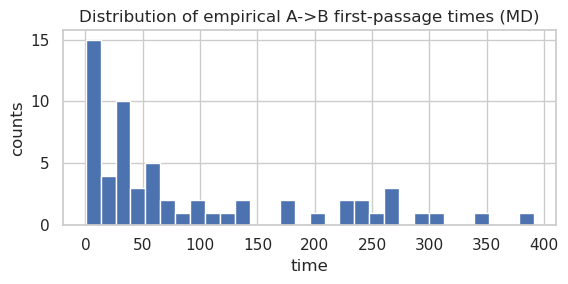

In [12]:
# Cell 10 — Estimate MD-derived generator K_md (moved earlier so it can be used for scaling)

def estimate_K_from_MD_labels(labels_md, dt_md, N):
    if labels_md is None:
        return None
    labels_md = np.asarray(labels_md, dtype=int)
    n = len(labels_md)
    changes = np.where(labels_md[1:] != labels_md[:-1])[0] + 1
    prev_states = labels_md[changes - 1]
    next_states = labels_md[changes]
    counts_md = np.zeros((N,N), dtype=float)
    for a,b in zip(prev_states, next_states):
        counts_md[int(a), int(b)] += 1
    change_frames = np.concatenate((changes, [n]))
    start_frames = np.concatenate(([0], changes))
    durations_frames = change_frames - start_frames
    states_during = labels_md[start_frames]
    time_in_state = np.zeros(N, dtype=float)
    for s, df in zip(states_during, durations_frames):
        time_in_state[int(s)] += df * (dt_md if dt_md is not None else 1.0)
    K_md = np.zeros((N,N), dtype=float)
    for i in range(N):
        if time_in_state[i] > 0:
            K_md[i, :] = counts_md[i, :] / time_in_state[i]
    for i in range(N):
        off_sum = np.sum(K_md[i, :]) - K_md[i, i]
        K_md[i, i] = -off_sum
    return K_md, time_in_state

K_md = None
md_time_in_state = None
if labels_md is not None:
    K_md_res = estimate_K_from_MD_labels(labels_md, dt_md, N)
    if K_md_res is not None:
        K_md, md_time_in_state = K_md_res
        logger.info('Estimated K_md from MD labels')

# inspect K_md
if K_md is not None:
    plt.figure(figsize=(6,5))
    plt.imshow(K_md, origin='lower')
    plt.title('K_md estimated from MD labels')
    plt.colorbar(); plt.tight_layout(); plt.show()

# If scale_method == 'md' and we have K_md, scale model accordingly
if PARAMS['scale_method'] == 'md' and K_md is not None:
    md_scale_by = PARAMS.get('md_scale_by', 'max_exit')
    if md_scale_by == 'max_exit':
        R_md = -np.diag(K_md)
        R_model = -np.diag(K)
        if np.max(R_md) > 0 and np.max(R_model) > 0:
            scale_md = np.max(R_model) / np.max(R_md)
            # user requested: "scale matrix based on MD matrix" — choose to scale K_model so that its max exit equals MD's
            # Here we set K_scaled = K * (max_md / max_model) to bring model to MD scale
            scale_md = np.max(R_md) / np.max(R_model)
            K_scaled = K * scale_md
            logger.info(f'scaling K by max_exit: factor {scale_md:.5g}')
    elif md_scale_by == 'frobenius':
        mask_off = ~np.eye(N, dtype=bool)
        fro_model = np.linalg.norm(K[mask_off])
        fro_md = np.linalg.norm(K_md[mask_off]) if K_md is not None else 0.0
        if fro_md > 0 and fro_model > 0:
            scale_md = fro_md / fro_model
            K_scaled = K * scale_md
            logger.info(f'scaling K by frobenius off-diag: factor {scale_md:.5g}')
    elif md_scale_by == 'slowest_exit':
        R_md = -np.diag(K_md)
        R_model = -np.diag(K)
        slow_md = np.min(R_md[R_md > 0]) if np.any(R_md > 0) else 0.0
        slow_model = np.min(R_model[R_model > 0]) if np.any(R_model > 0) else 0.0
        if slow_md > 0 and slow_model > 0:
            scale_md = slow_md / slow_model
            K_scaled = K * scale_md
            logger.info(f'scaling K by slowest_exit: factor {scale_md:.5g}')
    elif md_scale_by == 'slowest_mode':
        def get_slowest_eigval(Kmat, tol=1e-10):
            eigs = np.sort(np.real(np.linalg.eigvals(Kmat)))[::-1]
            nontrivial = eigs[eigs < -tol]
            return nontrivial[0] if len(nontrivial) > 0 else None
        
        lam_model = get_slowest_eigval(K)
        lam_md    = get_slowest_eigval(K_md)
        
        if lam_model is not None and lam_md is not None:
            c_slow = lam_md / lam_model
            K_scaled = K * c_slow
            logger.info(f'Slow-mode scaling: c={c_slow:.4g}, '
                        f'tau_model={-1/lam_model:.4g}, tau_md={-1/lam_md:.4g}')

# inspect scaled K
plt.figure(figsize=(6,5))
plt.imshow(K_scaled, origin='lower')
plt.title('K after scaling (final)')
plt.colorbar(); plt.tight_layout(); plt.show()

# confirm MFPT after scaling
t_model_to_B_scaled = mfpt_to_target_from_generator(K_scaled, B_idx)
mfpt_model_A_to_B_scaled = t_model_to_B_scaled[A_idx]
logger.info(f'Model MFPT A->B (after scaling) = {mfpt_model_A_to_B_scaled}')

if mfpt_md_mean is not None:
    print('\nMFPT comparison (A->B):')
    print(f'  MD empirical MFPT  : {mfpt_md_mean:.5g}')
    print(f'  Model (before)     : {mfpt_model_A_to_B:.5g}')
    print(f'  Model (after scale): {mfpt_model_A_to_B_scaled:.5g}')

if mfpt_md_mean is not None:
    plt.figure(figsize=(6,3))
    plt.hist(hit_times, bins=30)
    plt.title('Distribution of empirical A->B first-passage times (MD)')
    plt.xlabel('time'); plt.ylabel('counts'); plt.tight_layout(); plt.show()

Generated 540 events up to time 1e+04


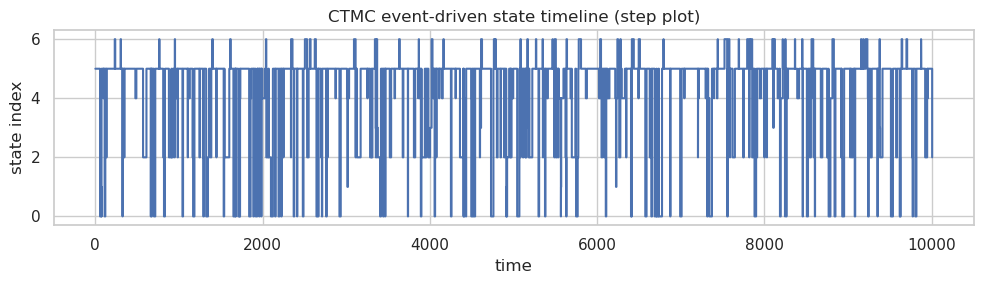

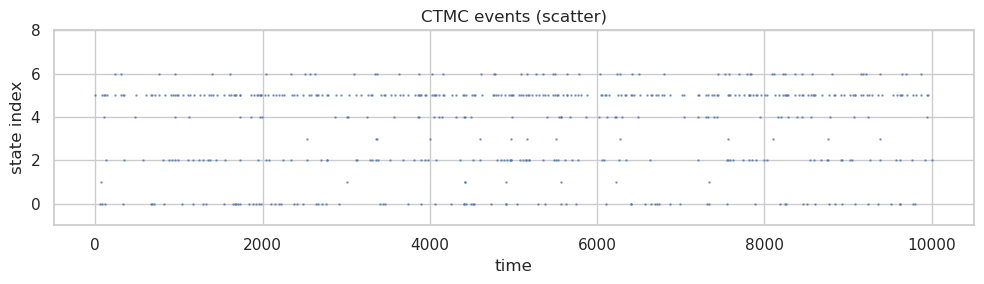

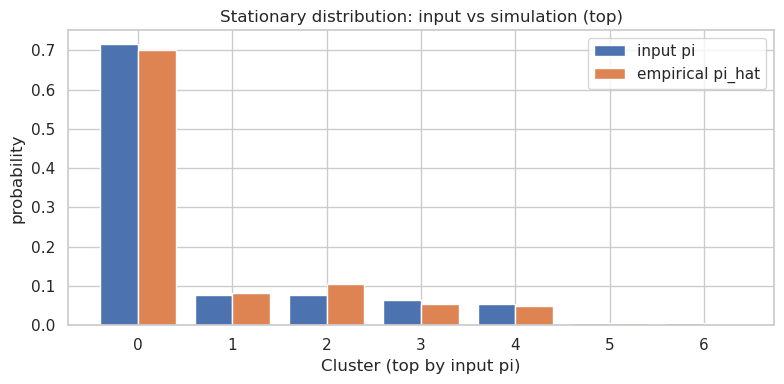

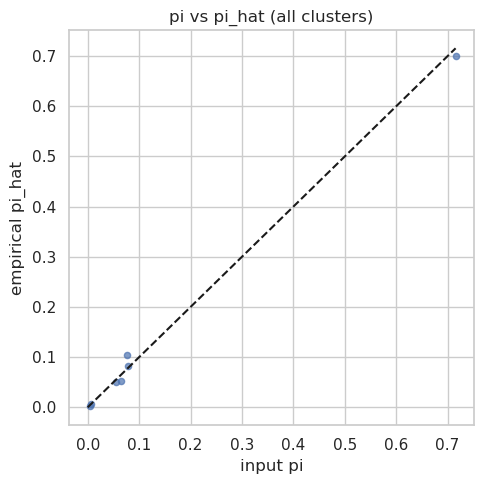

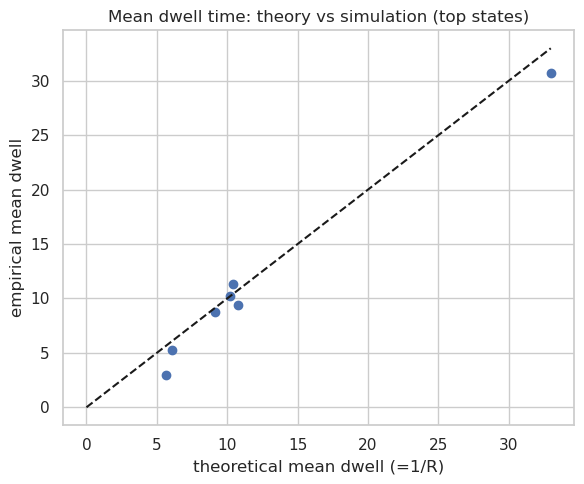

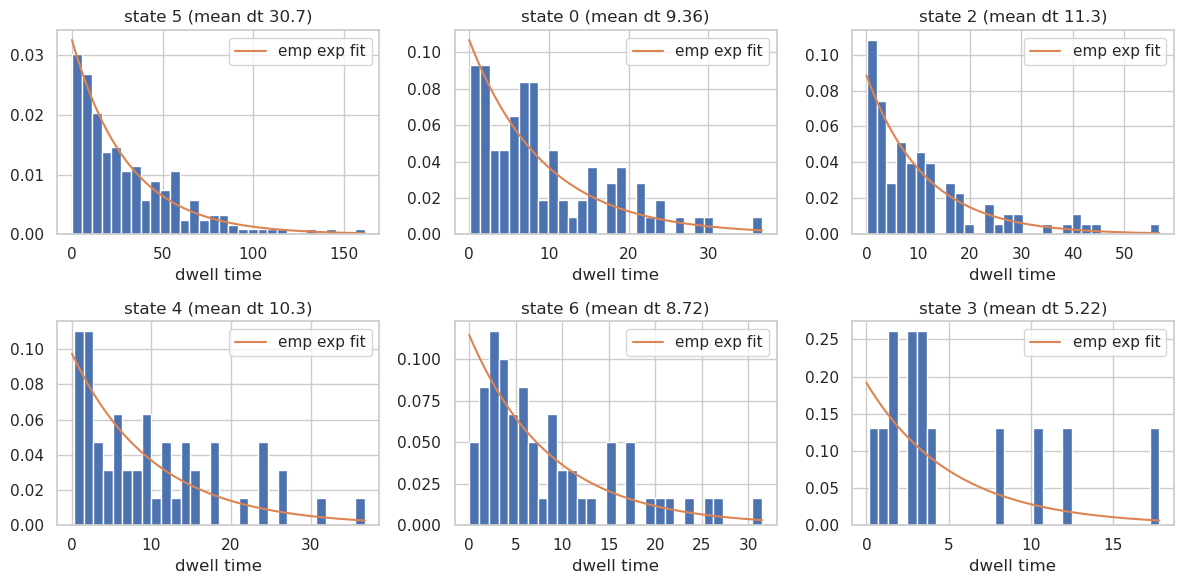

In [13]:
# Cell 11 — Gillespie simulation + single-run diagnostics and visualizations
# precompute neighbor arrays
neighbor_indices = [None] * N
neighbor_rates = [None] * N
neighbor_cumsums = [None] * N
neighbor_total_rates = np.zeros(N)
for i in range(N):
    nbrs = np.where(K_scaled[i] > 0)[0]
    if nbrs.size == 0:
        neighbor_indices[i] = np.array([], dtype=int)
        neighbor_rates[i] = np.array([], dtype=float)
        neighbor_cumsums[i] = np.array([], dtype=float)
        neighbor_total_rates[i] = 0.0
    else:
        rates = K_scaled[i, nbrs]
        cums = np.cumsum(rates)
        neighbor_indices[i] = nbrs
        neighbor_rates[i] = rates
        neighbor_cumsums[i] = cums
        neighbor_total_rates[i] = cums[-1]


def gillespie_ctmc_fast(neigh_idx, neigh_cums, neigh_tot, init_state, T_final, rng_local=None):
    if rng_local is None:
        rng_local = np.random.default_rng()
    state = int(init_state)
    t = 0.0
    times = [t]
    states = [state]
    local_log = math.log
    while t < T_final:
        R = neigh_tot[state]
        if R <= 0:
            logger.warning(f'Zero exit rate at state {state}; stopping simulation')
            break
        u = rng_local.random()
        dt = -local_log(u) / R
        v = rng_local.random() * R
        cums = neigh_cums[state]
        idx = np.searchsorted(cums, v, side='right')
        if idx >= len(neigh_idx[state]):
            idx = len(neigh_idx[state]) - 1
        next_state = int(neigh_idx[state][idx])
        t += dt
        times.append(t)
        states.append(next_state)
        state = next_state
    return np.array(times), np.array(states)

Tfinal = float(PARAMS['T_final'])
init = initial_cluster
times, states_seq = gillespie_ctmc_fast(neighbor_indices, neighbor_cumsums, neighbor_total_rates, init, 10000)
print(f'Generated {len(times)} events up to time {times[-1]:.3g}')

# timeline plot
plt.figure(figsize=(10,3))
plt.step(times, states_seq, where='post')
plt.xlabel('time'); plt.ylabel('state index')
plt.title('CTMC event-driven state timeline (step plot)')
plt.tight_layout(); plt.show()

plt.figure(figsize=(10,3))
plt.scatter(times, states_seq, s=0.7, alpha=0.6)
plt.xlabel('time'); plt.ylabel('state index')
plt.title('CTMC events (scatter)')
plt.ylim(-1, N+1)
plt.tight_layout(); plt.show()

# dwell times and pi_hat
durations = np.diff(times)
states_during = states_seq[:-1]

total_time = durations.sum()
time_per_state = np.zeros(N)
visit_counts = np.zeros(N, dtype=int)
for s, dt in zip(states_during, durations):
    time_per_state[int(s)] += dt
    visit_counts[int(s)] += 1

pi_hat = time_per_state / (total_time + 1e-300)

# compare pi
plt.figure(figsize=(8,4))
order = np.argsort(pi)[::-1]
plt.bar(np.arange(min(20,N))-0.2, pi[order][:min(20,N)], width=0.4, label='input pi')
plt.bar(np.arange(min(20,N))+0.2, pi_hat[order][:min(20,N)], width=0.4, label='empirical pi_hat')
plt.xlabel('Cluster (top by input pi)'); plt.ylabel('probability')
plt.legend(); plt.title('Stationary distribution: input vs simulation (top)')
plt.tight_layout(); plt.show()

plt.figure(figsize=(5,5))
plt.scatter(pi, pi_hat, s=20, alpha=0.7)
plt.plot([0, pi.max()], [0, pi.max()], '--k')
plt.xlabel('input pi'); plt.ylabel('empirical pi_hat'); plt.title('pi vs pi_hat (all clusters)')
plt.tight_layout(); plt.show()

# mean dwell comparison
R_scaled = -np.diag(K_scaled)
mean_dwell_empirical = np.zeros(N)
for i in range(N):
    if visit_counts[i] > 0:
        mean_dwell_empirical[i] = time_per_state[i] / visit_counts[i]
    else:
        mean_dwell_empirical[i] = np.nan
mean_dwell_theory = 1.0 / (R_scaled + 1e-300)

topk = min(20, N)
top_states = order[:topk]
plt.figure(figsize=(6,5))
plt.scatter(mean_dwell_theory[top_states], mean_dwell_empirical[top_states])
maxv = np.nanmax(np.concatenate([mean_dwell_theory[top_states], mean_dwell_empirical[top_states]]))
plt.plot([0, maxv], [0, maxv], '--k')
plt.xlabel('theoretical mean dwell (=1/R)'); plt.ylabel('empirical mean dwell')
plt.title('Mean dwell time: theory vs simulation (top states)')
plt.tight_layout(); plt.show()

# dwell histograms for example states
num_examples = min(6, N)
example_states = np.argsort(pi)[-num_examples:][::-1]
plt.figure(figsize=(12,6))
for idx, s in enumerate(example_states):
    plt.subplot(2,3,idx+1)
    mask = (states_during == s)
    dts = durations[mask]
    if dts.size == 0:
        plt.title(f'state {s}: no visits')
        continue
    plt.hist(dts, bins=30, density=True)
    mean_dt = dts.mean()
    xs = np.linspace(0, dts.max(), 200)
    plt.plot(xs, (1/mean_dt)*np.exp(-xs/mean_dt), label='emp exp fit')
    plt.title(f'state {s} (mean dt {mean_dt:.3g})')
    plt.xlabel('dwell time'); plt.legend()
plt.tight_layout(); plt.show()

Stationary distribution: KL(pi||pi_hat) = 0.00702, L1 error = 0.0684


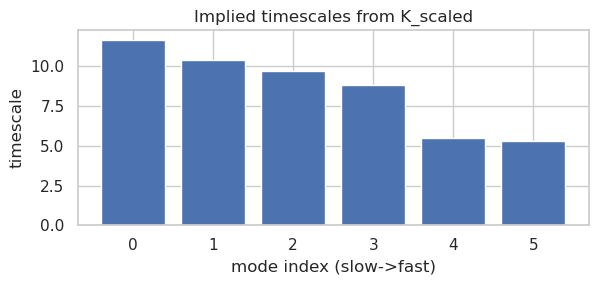

MFPT A->B comparison:
  Model (analytic from K) : 131.43
  MD empirical             : 93.894
  Simulation empirical     : 104.88


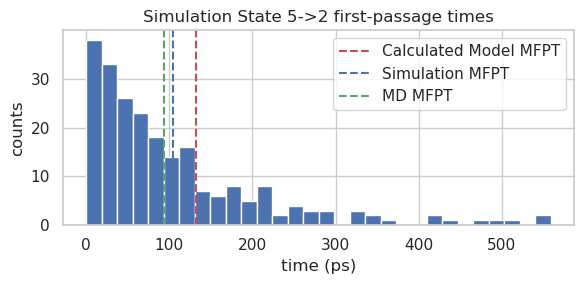

INFO:ctmc_nb:Saved ctmc_validation.npz with validation results


Total simulated time = 1e+04; visits per state (example top 10):
  state 5: pi=0.716, pi_hat=0.7, visits=228
  state 0: pi=0.0775, pi_hat=0.0823, visits=88
  state 2: pi=0.076, pi_hat=0.105, visits=93
  state 4: pi=0.0646, pi_hat=0.0533, visits=52
  state 6: pi=0.0552, pi_hat=0.0497, visits=57
  state 3: pi=0.00652, pi_hat=0.00679, visits=13
  state 1: pi=0.00464, pi_hat=0.0024, visits=8
Number of zero-exit-rate states: 0


In [14]:
# Cell 12 — Validation metrics: KL, L1, timescales, MFPT comp
# 1) Stationary distribution error
eps = 1e-12
kl_div = np.sum(pi * np.log((pi + eps) / (pi_hat + eps)))
l1_err = np.sum(np.abs(pi - pi_hat))
print(f"Stationary distribution: KL(pi||pi_hat) = {kl_div:.3g}, L1 error = {l1_err:.3g}")

# 2) implied timescales
eigvals = np.linalg.eigvals(K_scaled)
real_parts = np.real(eigvals)
mask = real_parts < -1e-12
timescales = -1.0 / real_parts[mask]
timescales_sorted = np.sort(timescales)[::-1]

plt.figure(figsize=(6,3))
m = min(10, timescales_sorted.size)
plt.bar(range(m), timescales_sorted[:m])
plt.xlabel('mode index (slow->fast)'); plt.ylabel('timescale')
plt.title('Implied timescales from K_scaled')
plt.tight_layout(); plt.show()

# 3) MFPT: model vs simulation vs MD (if available)
mfpt_model = float(mfpt_model_A_to_B_scaled)

def compute_empirical_mfpt_from_events(times, states, A_idx, B_idx):
    n = len(states)
    hits = []
    i = 0
    while i < n:
        if states[i] == A_idx:
            j = i+1
            while j < n and states[j] != B_idx:
                j += 1
            if j < n and states[j] == B_idx:
                hits.append(times[j] - times[i])
            while i < n and states[i] == A_idx:
                i += 1
        else:
            i += 1
    if len(hits) == 0:
        return None, None
    return float(np.mean(hits)), np.array(hits)

mfpt_sim_mean, mfpt_sim_hits = compute_empirical_mfpt_from_events(times, states_seq, A_idx, B_idx)
print('MFPT A->B comparison:')
print(f'  Model (analytic from K) : {mfpt_model:.5g}')
if mfpt_md_mean is not None:
    print(f'  MD empirical             : {mfpt_md_mean:.5g}')
if mfpt_sim_mean is not None:
    print(f'  Simulation empirical     : {mfpt_sim_mean:.5g}')

if mfpt_sim_hits is not None and len(mfpt_sim_hits) > 0:
    plt.figure(figsize=(6,3))
    plt.hist(mfpt_sim_hits, bins=30)
    plt.axvline(mfpt_model, color='r', linestyle='--', label='Calculated Model MFPT')
    plt.axvline(mfpt_sim_mean, color='b', linestyle='--', label='Simulation MFPT')
    if mfpt_md_mean is not None:
        plt.axvline(mfpt_md_mean, color='g', linestyle='--', label='MD MFPT')
    plt.title('Simulation State 5->2 first-passage times')
    plt.xlabel('time (ps)'); plt.ylabel('counts'); plt.legend(); plt.tight_layout(); plt.show()
else:
    logger.info('No A->B first-passage events observed in simulation.')

# 4) visits and zero-rate states
zero_rate_states = np.sum(neighbor_total_rates <= 0)
print(f"Total simulated time = {total_time:.3g}; visits per state (example top 10):")
for s in order[:10]:
    print(f"  state {s}: pi={pi[s]:.3g}, pi_hat={pi_hat[s]:.3g}, visits={visit_counts[s]}")
print(f"Number of zero-exit-rate states: {zero_rate_states}")

# save validation outputs
np.savez(os.path.join(PARAMS['outputs_dir'], 'ctmc_validation.npz'), pi=pi, pi_hat=pi_hat, times=times, states=states_seq,
         mfpt_sim_hits=mfpt_sim_hits if mfpt_sim_hits is not None else np.array([]),
         timescales=timescales_sorted)
logger.info('Saved ctmc_validation.npz with validation results')

INFO:ctmc_nb:Producing MD-side diagnostic plots for visual comparison


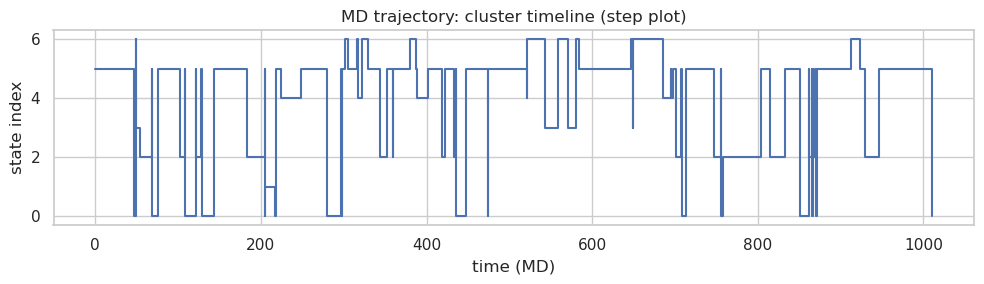

MD vs Model generator comparison (masked rows):
  Compared entries = 24
  Frobenius norm (off-diag masked) of K_md = 0.15978
  Frobenius norm of difference = 0.047578 (relative = 0.298)
  Pearson corr (off-diag masked) = 0.9450537736708786
  Mean abs relative error (where K_md>0) = 0.483


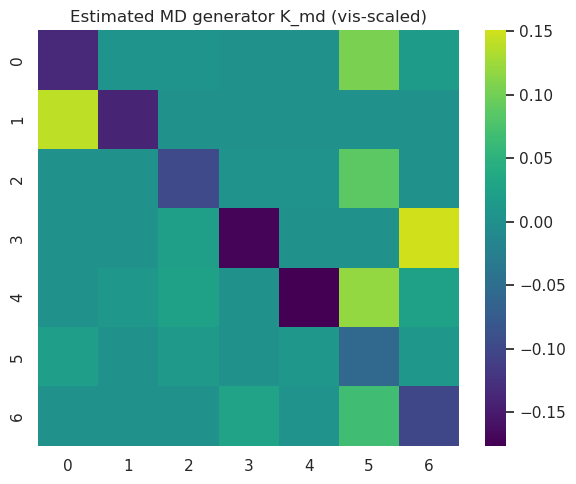

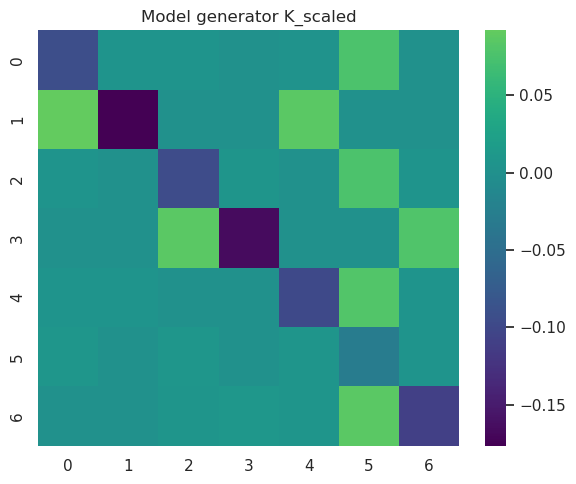

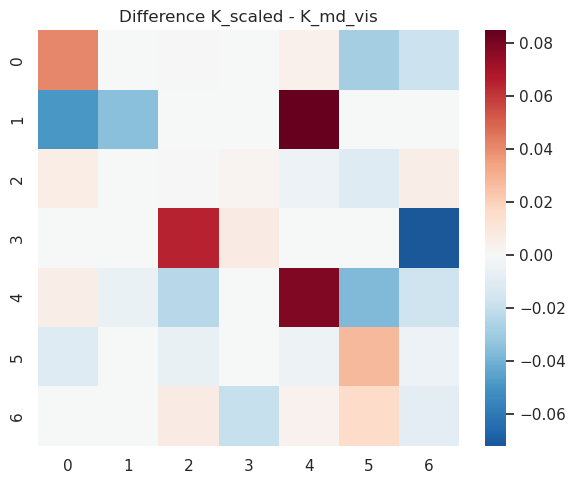

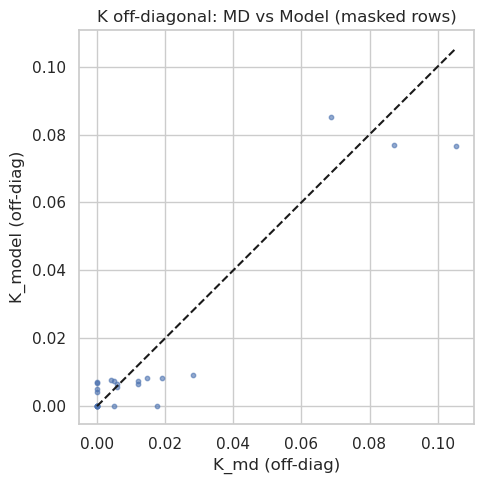

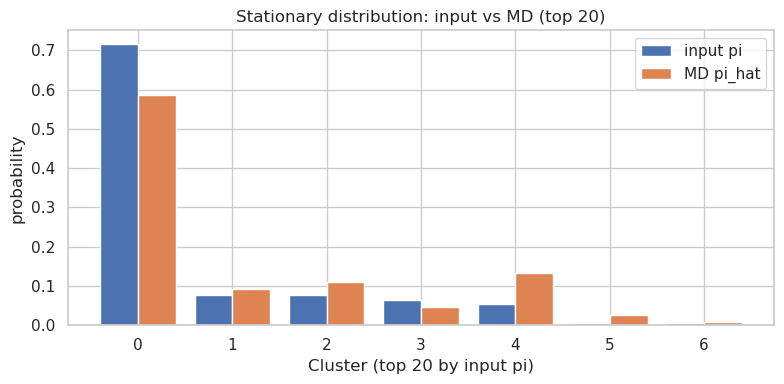

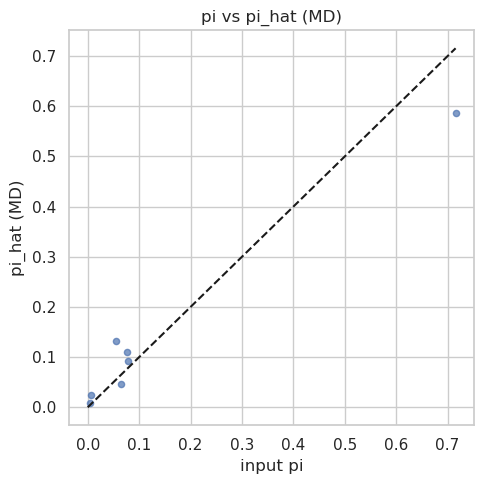

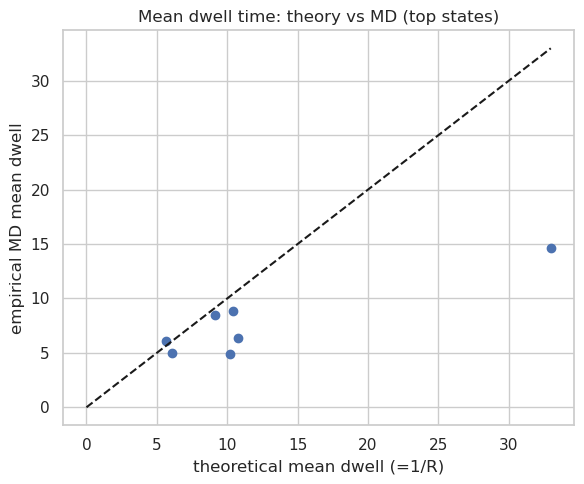

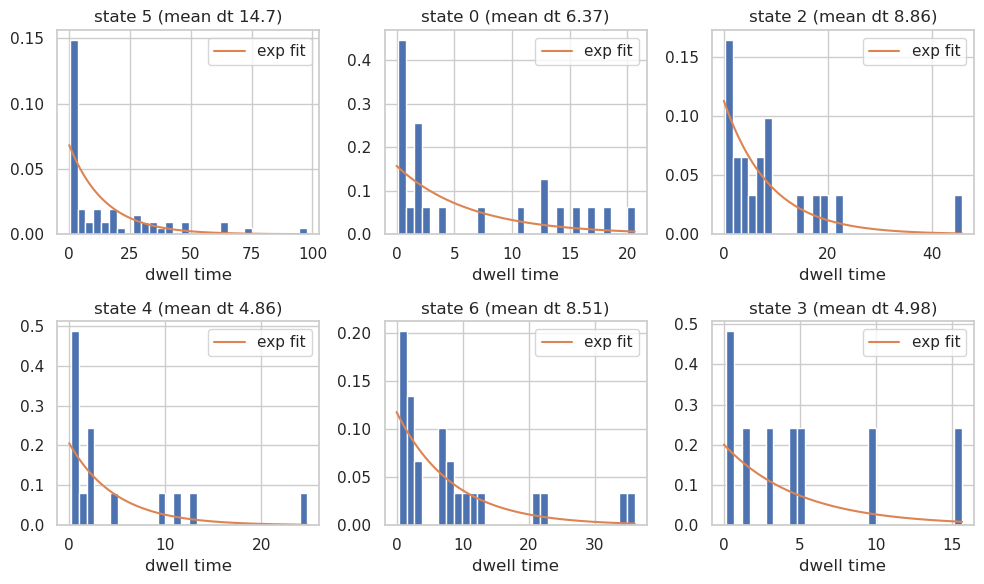

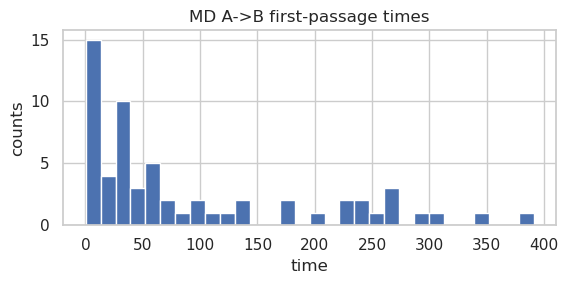

In [15]:
# Cell 13 — MD-side diagnostics: timelines, K_md comparison, plots
if feats_md is not None and labels_md is not None:
    logger.info('Producing MD-side diagnostic plots for visual comparison')
    n_md = len(labels_md)
    times_md = np.arange(n_md, dtype=float) * dt_md
    changes = np.where(labels_md[1:] != labels_md[:-1])[0] + 1
    times_md_events = np.concatenate(([0.0], times_md[changes]))
    states_md_seq = np.concatenate(([int(labels_md[0])], labels_md[changes].astype(int)))

    plt.figure(figsize=(10,3))
    cutoff = min(100, len(times_md_events))
    plt.step(times_md_events[:cutoff], states_md_seq[:cutoff], where='post')
    plt.xlabel('time (MD)'); plt.ylabel('state index')
    plt.title('MD trajectory: cluster timeline (step plot)')
    plt.tight_layout(); plt.show()

    # MD dwell aggregation
    change_frames = np.concatenate((changes, [n_md]))
    start_frames = np.concatenate(([0], changes))
    durations_frames = change_frames - start_frames
    durations_time = durations_frames * dt_md
    states_during_md = labels_md[start_frames]

    time_per_state_md = np.zeros(N)
    visit_counts_md = np.zeros(N, dtype=int)
    for s, dt_ in zip(states_during_md, durations_time):
        time_per_state_md[int(s)] += dt_
        visit_counts_md[int(s)] += 1
    total_time_md = durations_time.sum()
    pi_hat_md = time_per_state_md / (total_time_md + 1e-300)

    # Save K_md
    np.save(os.path.join(PARAMS['outputs_dir'], 'K_md.npy'), K_md)

    # comparison metrics
    K_md_local = K_md.copy()
    # optionally scale K_md visually to match K_scaled exit rates
    R_md = -np.diag(K_md_local)
    R_scaled = -np.diag(K_scaled)
    if R_md.max() > 0 and R_scaled.max() > 0:
        scale_vis = R_scaled.max() / R_md.max()
        K_md_vis = K_md_local * scale_vis
    else:
        K_md_vis = K_md_local

    # masked comparison
    K_model_all = K_scaled.copy()
    mask_off = ~np.eye(N, dtype=bool)
    row_mask = time_per_state_md >= max(1e-12, 0.05 * total_time_md)
    row_mask_mat = np.repeat(row_mask[:, None], N, axis=1)
    compare_mask = mask_off & row_mask_mat

    k_model_flat = K_model_all[compare_mask]
    k_md_flat = K_md_vis[compare_mask]
    finite_mask = np.isfinite(k_model_flat) & np.isfinite(k_md_flat)
    k_model_flat = k_model_flat[finite_mask]
    k_md_flat = k_md_flat[finite_mask]

    fro_diff = np.linalg.norm(k_model_flat - k_md_flat) if k_model_flat.size>0 else np.nan
    fro_md = np.linalg.norm(k_md_flat) if k_md_flat.size>0 else np.nan
    rel_fro = fro_diff / (fro_md + 1e-300) if not np.isnan(fro_md) else np.nan
    corr = np.corrcoef(k_model_flat, k_md_flat)[0,1] if k_model_flat.size>2 else np.nan
    nonzero_md = np.abs(k_md_flat) > 1e-12
    mare = np.mean(np.abs((k_model_flat[nonzero_md] - k_md_flat[nonzero_md]) / (k_md_flat[nonzero_md] + 1e-12))) if np.any(nonzero_md) else np.nan

    print('MD vs Model generator comparison (masked rows):')
    print(f'  Compared entries = {k_md_flat.size}')
    print(f'  Frobenius norm (off-diag masked) of K_md = {fro_md:.5g}')
    print(f'  Frobenius norm of difference = {fro_diff:.5g} (relative = {rel_fro:.3g})')
    print(f'  Pearson corr (off-diag masked) = {corr}')
    print(f'  Mean abs relative error (where K_md>0) = {mare:.3g}')

    # visualizations
    plt.figure(figsize=(6,5))
    sns.heatmap(K_md_vis, cmap='viridis', center=0)
    plt.title('Estimated MD generator K_md (vis-scaled)')
    plt.tight_layout(); plt.show()

    plt.figure(figsize=(6,5))
    sns.heatmap(K_scaled, cmap='viridis', center=0)
    plt.title('Model generator K_scaled')
    plt.tight_layout(); plt.show()

    diff_mat = K_scaled - K_md_vis
    plt.figure(figsize=(6,5))
    sns.heatmap(diff_mat, cmap='RdBu_r', center=0)
    plt.title('Difference K_scaled - K_md_vis')
    plt.tight_layout(); plt.show()

    # scatter
    if k_md_flat.size > 0:
        plt.figure(figsize=(5,5))
        plt.scatter(k_md_flat, k_model_flat, s=10, alpha=0.6)
        mx = max(k_md_flat.max(), k_model_flat.max())
        mn = min(k_md_flat.min(), k_model_flat.min())
        plt.plot([mn, mx], [mn, mx], '--k')
        plt.xlabel('K_md (off-diag)'); plt.ylabel('K_model (off-diag)')
        plt.title('K off-diagonal: MD vs Model (masked rows)')
        plt.tight_layout(); plt.show()

    # pi comparison
    order = np.argsort(pi)[::-1]
    top_k = min(20, N)
    plt.figure(figsize=(8,4))
    plt.bar(np.arange(top_k)-0.2, pi[order][:top_k], width=0.4, label='input pi')
    plt.bar(np.arange(top_k)+0.2, pi_hat_md[order][:top_k], width=0.4, label='MD pi_hat')
    plt.xlabel('Cluster (top 20 by input pi)'); plt.ylabel('probability')
    plt.legend(); plt.title('Stationary distribution: input vs MD (top 20)')
    plt.tight_layout(); plt.show()

    plt.figure(figsize=(5,5))
    plt.scatter(pi, pi_hat_md, s=20, alpha=0.7)
    plt.plot([0, pi.max()], [0, pi.max()], '--k')
    plt.xlabel('input pi'); plt.ylabel('pi_hat (MD)'); plt.title('pi vs pi_hat (MD)')
    plt.tight_layout(); plt.show()

    # mean dwell comparison MD vs theory
    mean_dwell_empirical_md = np.zeros(N)
    for i in range(N):
        if visit_counts_md[i] > 0:
            mean_dwell_empirical_md[i] = time_per_state_md[i] / visit_counts_md[i]
        else:
            mean_dwell_empirical_md[i] = np.nan
    plt.figure(figsize=(6,5))
    topk = min(20, N)
    top_states = order[:topk]
    plt.scatter(mean_dwell_theory[top_states], mean_dwell_empirical_md[top_states])
    maxv = np.nanmax(np.concatenate([mean_dwell_theory[top_states], mean_dwell_empirical_md[top_states]]))
    plt.plot([0, maxv], [0, maxv], '--k')
    plt.xlabel('theoretical mean dwell (=1/R)'); plt.ylabel('empirical MD mean dwell')
    plt.title('Mean dwell time: theory vs MD (top states)')
    plt.tight_layout(); plt.show()

    # MD dwell histograms for example states
    plt.figure(figsize=(10,6))
    for idx, s in enumerate(example_states):
        plt.subplot(2,3,idx+1)
        mask = (states_during_md == s)
        dts = durations_time[mask]
        if dts.size == 0:
            plt.title(f'state {s}: no visits')
            continue
        plt.hist(dts, bins=30, density=True)
        mean_dt = dts.mean()
        xs = np.linspace(0, dts.max(), 200)
        plt.plot(xs, (1/mean_dt)*np.exp(-xs/mean_dt), label='exp fit')
        plt.title(f'state {s} (mean dt {mean_dt:.3g})')
        plt.xlabel('dwell time'); plt.legend()
    plt.tight_layout(); plt.show()

    # MD MFPT histogram if available
    if mfpt_md_mean is not None:
        plt.figure(figsize=(6,3))
        plt.hist(hit_times, bins=30)
        plt.title('MD A->B first-passage times')
        plt.xlabel('time'); plt.ylabel('counts'); plt.tight_layout(); plt.show()

else:
    logger.info('MD features or labels not available; skipping MD-side diagnostics')

INFO:ctmc_nb:Running 50 CTMC simulations for averaging...


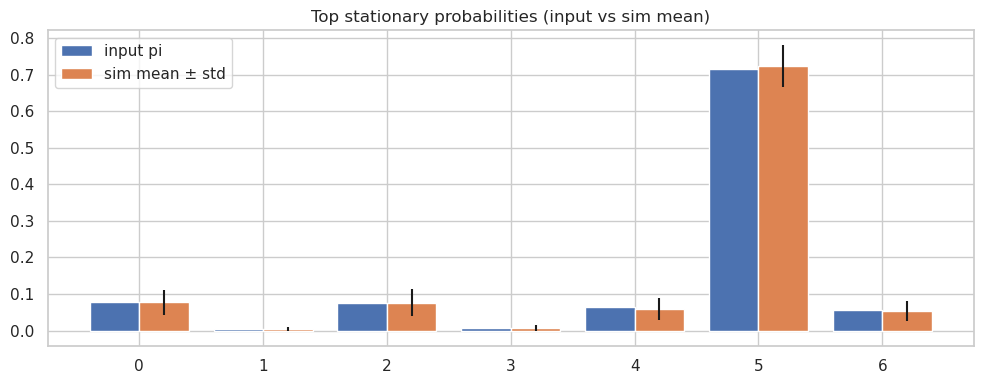

INFO:ctmc_nb:Loading MD trajectories from directory pentane-md
INFO:ctmc_nb:Processed MD file pentane-md/fit-short-trajectory-80.pdb
INFO:ctmc_nb:Processed MD file pentane-md/multiple-short-trajectory-80_1.pdb
INFO:ctmc_nb:Processed MD file pentane-md/multiple-short-trajectory-80_2.pdb
INFO:ctmc_nb:Processed MD file pentane-md/multiple-short-trajectory-80_3.pdb
INFO:ctmc_nb:Processed MD file pentane-md/multiple-short-trajectory-80_4.pdb
INFO:ctmc_nb:Processed MD file pentane-md/multiple-short-trajectory-80_5.pdb
INFO:ctmc_nb:Processed MD file pentane-md/multiple-short-trajectory_1-freq-80.dcd
INFO:ctmc_nb:Processed MD file pentane-md/multiple-short-trajectory_100-freq-80.dcd
INFO:ctmc_nb:Processed MD file pentane-md/multiple-short-trajectory_103-freq-80.dcd
INFO:ctmc_nb:Processed MD file pentane-md/multiple-short-trajectory_11-freq-80.dcd
INFO:ctmc_nb:Processed MD file pentane-md/multiple-short-trajectory_14-freq-80.dcd
INFO:ctmc_nb:Processed MD file pentane-md/multiple-short-trajector

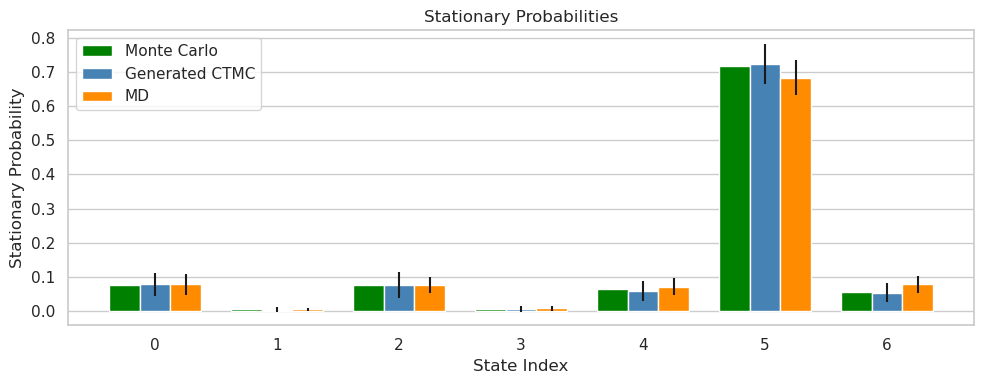

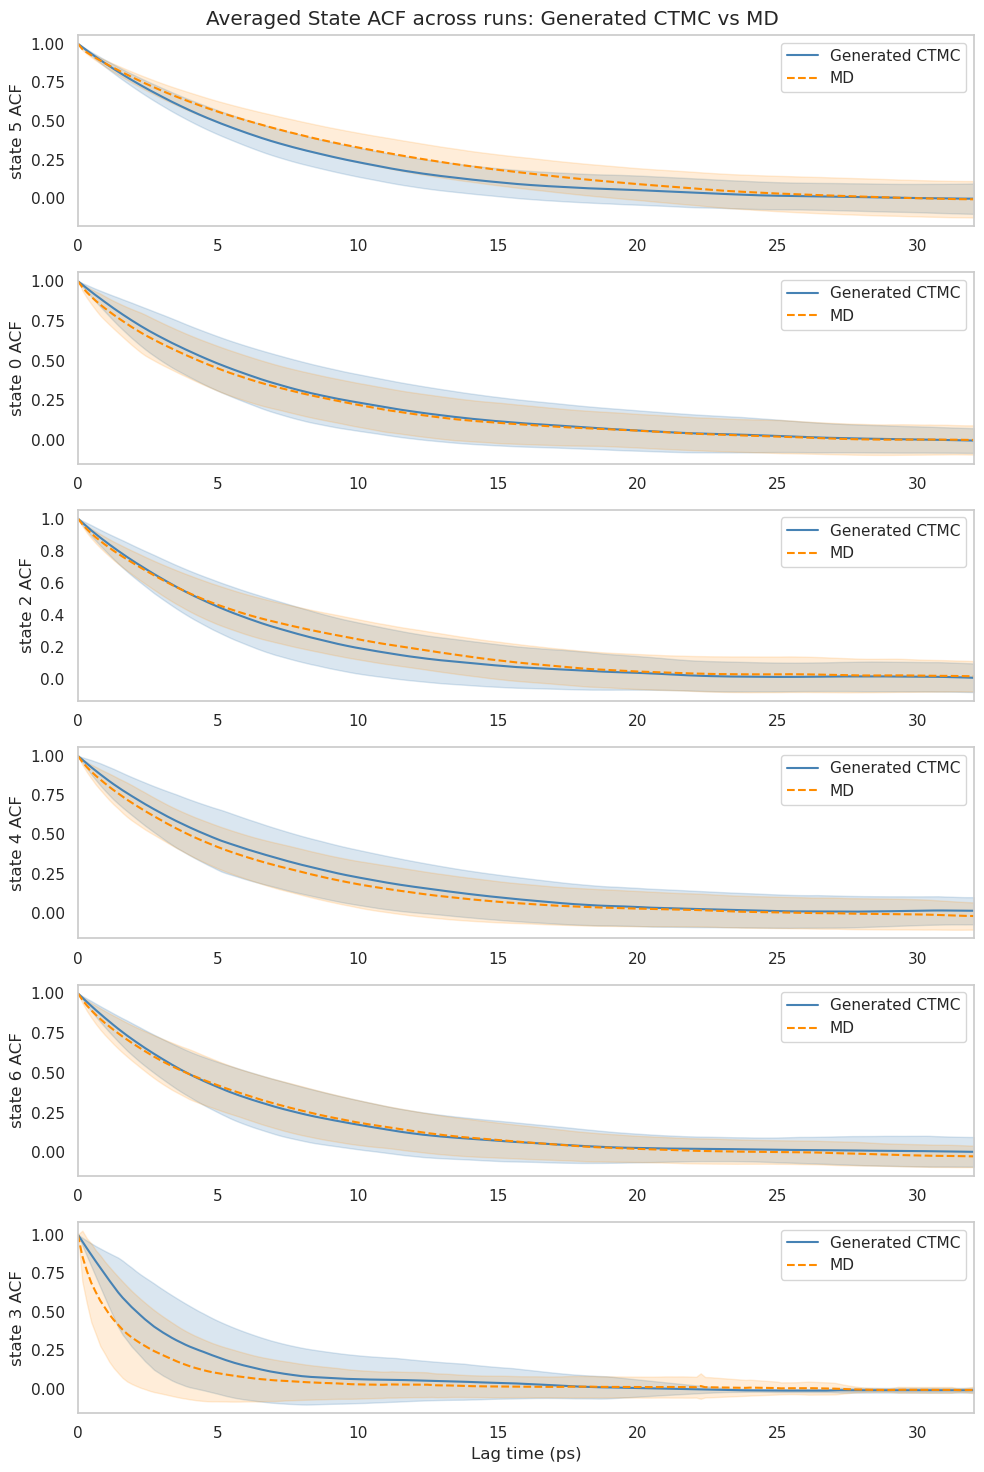

INFO:ctmc_nb:Built K_md_combined from all MD trajectories
INFO:ctmc_nb:Slow-mode scaling: c=1.801, tau_model=11.68, tau_md=6.484


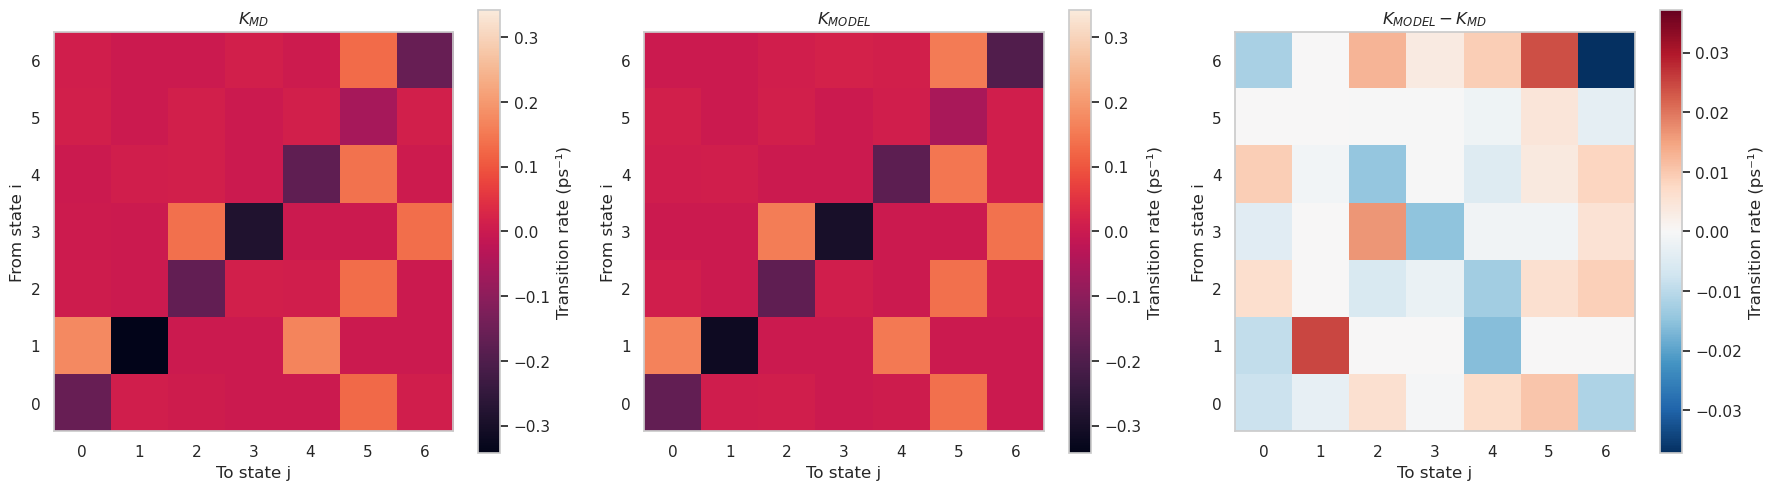

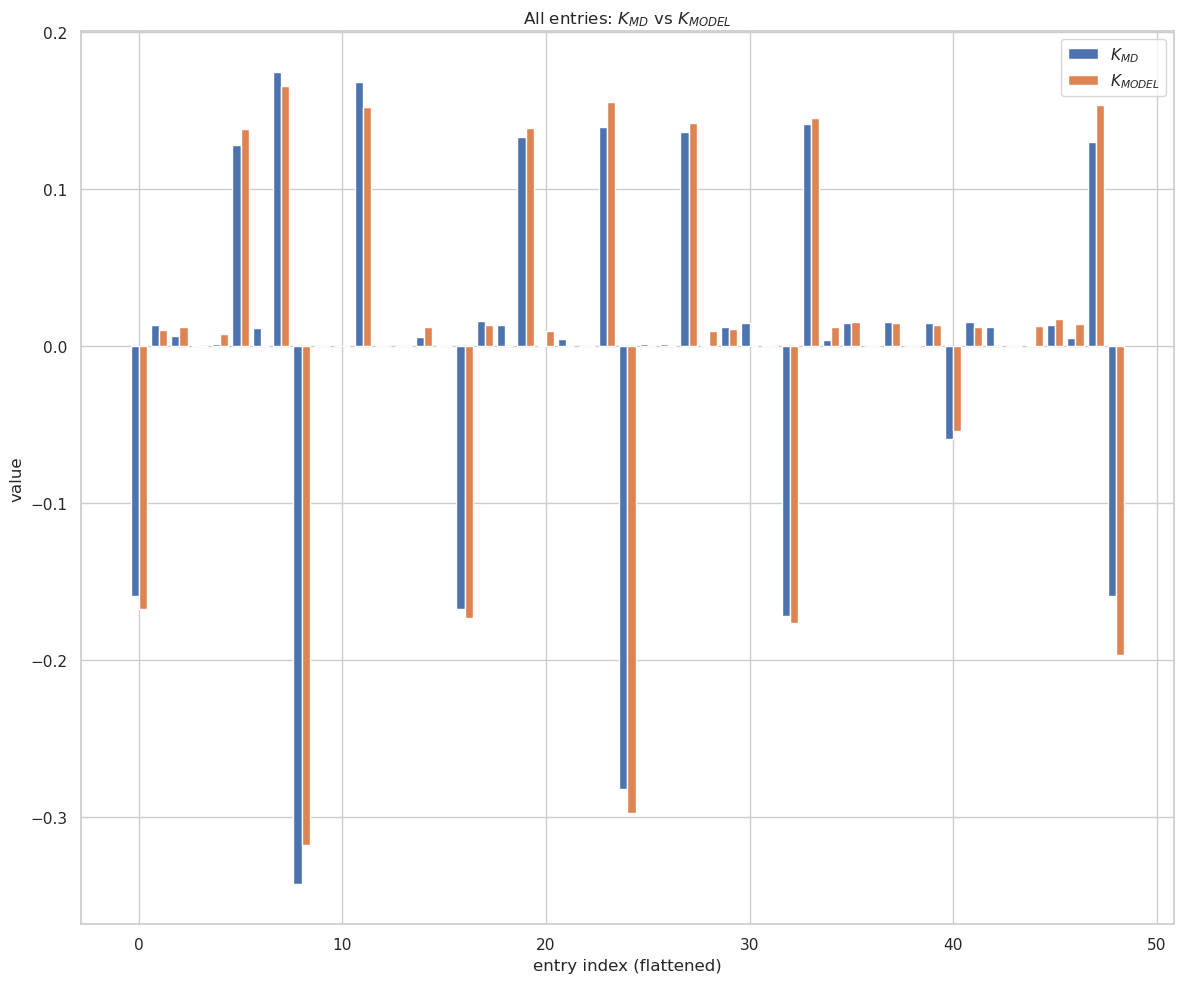


Combined MD vs Model generator comparison (masked rows):
  MD files used          = 56
  Compared entries       = 30
  Frobenius norm K_md    = 0.27036
  Frobenius norm diff    = 0.044946  (relative = 0.166)
  Pearson corr           = 0.9872687872214247
  MARE (where K_md > 0) = 7.34


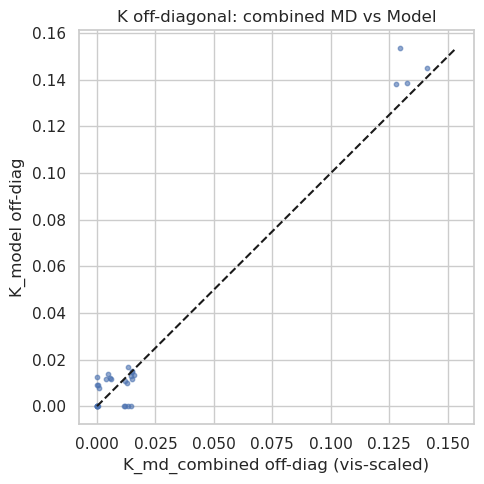

INFO:ctmc_nb:Saved K_md_combined.npy
INFO:ctmc_nb:Saved summary metrics


In [16]:
# Cell 14 — Multi-run simulations, averaging & ACF comparisons
# ---------------------------------------------------------------
# Changes vs previous version:
#   1. MD ACF (from all md_dir trajectories) is now overlaid on sim ACF plots
#   2. A combined K_md_combined is built from all MD files and compared to K_scaled

sim_runs = int(PARAMS['sim_runs'])
sim_pi_hats = []
sim_time_per_state = []
sim_total_times = []
sim_times_list = []
sim_states_list = []

logger.info(f'Running {sim_runs} CTMC simulations for averaging...')
for run_idx in range(sim_runs):
    if PARAMS['sim_random_start']:
        start = int(rng.integers(0, N))
    else:
        start = initial_cluster
    times_r, states_r = gillespie_ctmc_fast(
        neighbor_indices,
        neighbor_cumsums,
        neighbor_total_rates,
        start,
        Tfinal
    )
    sim_times_list.append(times_r)
    sim_states_list.append(states_r)

    durations_r = np.diff(times_r)
    states_during_r = states_r[:-1]
    time_per_state_run = np.zeros(N)
    for s, dt_ in zip(states_during_r, durations_r):
        time_per_state_run[int(s)] += dt_
    total_time_run = durations_r.sum()
    pi_hat_run = time_per_state_run / (total_time_run + 1e-300)

    sim_pi_hats.append(pi_hat_run)
    sim_time_per_state.append(time_per_state_run)
    sim_total_times.append(total_time_run)

sim_pi_hats_arr = np.vstack(sim_pi_hats)
sim_pi_mean = np.nanmean(sim_pi_hats_arr, axis=0)
sim_pi_std = np.nanstd(sim_pi_hats_arr, axis=0)

plt.figure(figsize=(10, 4))
# order = np.argsort(pi)[::-1]
# let order be as before, no sorting
order = np.arange(N)
x = np.arange(min(20, N))
plt.bar(x - 0.2, pi[order][:len(x)], width=0.4, label='input pi')
plt.bar(x + 0.2, sim_pi_mean[order][:len(x)], width=0.4,
        yerr=sim_pi_std[order][:len(x)], label='sim mean ± std')
plt.legend()
plt.title('Top stationary probabilities (input vs sim mean)')
plt.tight_layout()
plt.show()


# ============================================================
# Load all MD trajectories from directory (used for both
# population plot, ACF overlay, and combined K_md)
# ============================================================
md_pi_hat_mean = None

# Accumulators for combined K_md across all MD files
counts_md_combined   = np.zeros((N, N), dtype=float)
time_in_state_combined = np.zeros(N, dtype=float)

# Storage for per-file MD labels on a common time grid (for ACF)
md_acf_per_file = []   # each entry: array of shape (N, Klags+1)

# -------- ACF helpers (defined here so they're available below) --------
Klags   = 200
Tcomp   = min(np.min(sim_total_times), Tfinal)
if Tcomp <= 0:
    Tcomp = Tfinal
dt_grid   = dt_md if dt_md is not None else (Tcomp / 1000.0)
n_samples = int(min(5000, max(200, math.floor(Tcomp / dt_grid))))
t_grid_common = np.linspace(0.0, Tcomp, n_samples)


def compute_acf(x, max_lag=None):
    x = np.asarray(x, dtype=float)
    n = x.size
    if n < 2:
        return np.array([1.0])
    if max_lag is None:
        max_lag = n - 1
    max_lag = min(max_lag, n - 1)
    x_mean  = x.mean()
    x_cent  = x - x_mean
    acf_full = np.correlate(x_cent, x_cent, mode='full')
    acf  = acf_full[n - 1: n - 1 + (max_lag + 1)]
    denom = np.arange(n, n - len(acf), -1)
    acf  = acf / denom
    if acf[0] == 0:
        return acf
    acf = acf / acf[0]
    return acf


if PARAMS['md_dir'] is not None and os.path.isdir(PARAMS['md_dir']):
    logger.info(f"Loading MD trajectories from directory {PARAMS['md_dir']}")
    md_files = sorted([
        os.path.join(PARAMS['md_dir'], f)
        for f in os.listdir(PARAMS['md_dir'])
        if f.endswith(('.dcd', '.xtc', '.pdb'))
    ])
    md_pi_hat_list = []
    md_labels_list = []

    for mdf in md_files:
        try:
            tr     = load_trajectory(mdf, PARAMS['md_topology'])
            feats  = compute_features(tr, use_dihedrals=PARAMS['use_dihedrals'])
            labs   = np.argmin(cdist(feats, centroids), axis=1)
            md_labels_list.append(labs)
            dt_local = infer_dt(tr)
            if dt_local is None:
                dt_local = dt_md
            ############################### debug
            dt_local = dt_md
            ###############################
            n_frames = len(labs)

            # ---- population pi_hat for this file ----
            changes_f      = np.where(labs[1:] != labs[:-1])[0] + 1
            start_frames_f = np.concatenate(([0], changes_f))
            end_frames_f   = np.concatenate((changes_f, [n_frames]))
            dur_frames_f   = end_frames_f - start_frames_f
            dur_time_f     = dur_frames_f * dt_local
            states_block_f = labs[start_frames_f]

            time_per_state_f = np.zeros(N)
            for s, dt_ in zip(states_block_f, dur_time_f):
                time_per_state_f[int(s)] += dt_
            total_time_f    = dur_time_f.sum()
            pi_hat_f        = time_per_state_f / (total_time_f + 1e-300)
            md_pi_hat_list.append(pi_hat_f)

            # ---- accumulate counts & time for combined K_md ----
            prev_states_f = labs[changes_f - 1]
            next_states_f = labs[changes_f]
            for a, b in zip(prev_states_f, next_states_f):
                counts_md_combined[int(a), int(b)] += 1
            for s, dt_ in zip(states_block_f, dur_time_f):
                time_in_state_combined[int(s)] += dt_

            # ---- ACF for this MD file on the common grid ----
            times_md_f  = np.arange(n_frames, dtype=float) * dt_local
            grid_idxs_f = np.searchsorted(times_md_f, t_grid_common, side='right') - 1
            grid_idxs_f = np.clip(grid_idxs_f, 0, n_frames - 1)
            labs_grid_f = labs[grid_idxs_f]

            acf_this_file = np.full((N, Klags + 1), np.nan)
            for s in range(N):
                ind = (labs_grid_f == s).astype(float)
                if ind.sum() < 3:
                    continue
                acf = compute_acf(ind, max_lag=Klags)
                L   = len(acf)
                acf_this_file[s, :L] = acf
            md_acf_per_file.append(acf_this_file)

            logger.info(f"Processed MD file {mdf}")
        except Exception as e:
            logger.warning(f"Failed to process {mdf}: {e}")

    # ---- population bar chart (3-bar: input / sim / MD) ----
    if len(md_pi_hat_list) > 0:
        md_pi_hat_arr  = np.vstack(md_pi_hat_list)
        md_pi_hat_mean = np.nanmean(md_pi_hat_arr, axis=0)
        md_pi_hat_std  = np.nanstd(md_pi_hat_arr, axis=0)

        plt.figure(figsize=(10, 4))
        plt.bar(x - 0.25, pi[order][:len(x)],            width=0.25, label='Monte Carlo', color='green')
        plt.bar(x,         sim_pi_mean[order][:len(x)],  width=0.25,
                yerr=sim_pi_std[order][:len(x)],          label='Generated CTMC', color='steelblue')
        plt.bar(x + 0.25, md_pi_hat_mean[order][:len(x)], width=0.25,
                yerr=md_pi_hat_std[order][:len(x)],        label='MD', color='darkorange')
        plt.legend()
        plt.xlabel('State Index')
        plt.ylabel('Stationary Probability')
        plt.title('Stationary Probabilities')
        plt.grid(axis='x')
        # only show integer state indices on x-axis
        plt.xticks(x, [str(int(i)) for i in x])
        plt.tight_layout()
        plt.show()


# ============================================================
# CHANGE 1 — Averaged ACF: simulation + MD overlay
# ============================================================
sim_acf_per_state = np.full((sim_runs, N, Klags + 1), np.nan)

for r in range(sim_runs):
    times_r  = sim_times_list[r]
    states_r = sim_states_list[r]
    sim_idxs = np.searchsorted(times_r, t_grid_common, side='right') - 1
    sim_idxs[sim_idxs < 0] = 0
    labels_sim_grid = states_r[sim_idxs]
    for s in range(N):
        ind = (labels_sim_grid == s).astype(float)
        if ind.sum() < 3:
            continue
        acf = compute_acf(ind, max_lag=Klags)
        L   = len(acf)
        sim_acf_per_state[r, s, :L] = acf

sim_acf_mean = np.nanmean(sim_acf_per_state, axis=0)
sim_acf_std  = np.nanstd(sim_acf_per_state,  axis=0)

# MD ACF mean/std across files
have_md_acf = len(md_acf_per_file) > 0
if have_md_acf:
    md_acf_arr  = np.stack(md_acf_per_file, axis=0)   # (n_files, N, Klags+1)
    md_acf_mean = np.nanmean(md_acf_arr, axis=0)
    md_acf_std  = np.nanstd(md_acf_arr,  axis=0)

states_to_plot = example_states
lags = np.arange(Klags + 1) * dt_grid

plt.figure(figsize=(10, 2.5 * len(states_to_plot)))
for idx, s in enumerate(states_to_plot):
    plt.subplot(len(states_to_plot), 1, idx + 1)

    # Simulation ACF
    plt.plot(lags, sim_acf_mean[s], color='steelblue', label='Generated CTMC')
    plt.fill_between(lags,
                     sim_acf_mean[s] - sim_acf_std[s],
                     sim_acf_mean[s] + sim_acf_std[s],
                     alpha=0.2, color='steelblue')

    # MD ACF overlay (Change 1)
    if have_md_acf:
        plt.plot(lags, md_acf_mean[s], color='darkorange', linestyle='--', label='MD')
        plt.fill_between(lags,
                         md_acf_mean[s] - md_acf_std[s],
                         md_acf_mean[s] + md_acf_std[s],
                         alpha=0.15, color='darkorange')

    plt.ylabel(f'state {s} ACF')
    plt.legend()
    plt.grid(False)
    plt.xlim(0, lags[-1])


plt.xlabel('Lag time (ps)')
plt.suptitle('Averaged State ACF across runs: Generated CTMC vs MD')
plt.tight_layout()
plt.show()


# ============================================================
# CHANGE 2 — Combined K_md from all MD files vs K_scaled
# ============================================================
K_md_combined = None

if time_in_state_combined.sum() > 0:
    K_md_combined = np.zeros((N, N), dtype=float)
    for i in range(N):
        if time_in_state_combined[i] > 0:
            K_md_combined[i, :] = counts_md_combined[i, :] / time_in_state_combined[i]
    for i in range(N):
        off_sum = np.sum(K_md_combined[i, :]) - K_md_combined[i, i]
        K_md_combined[i, i] = -off_sum

    logger.info('Built K_md_combined from all MD trajectories')

    # # --- vis-scale K_md_combined to match K_scaled exit rates ---
    # R_md_comb   = -np.diag(K_md_combined)
    # R_scaled_comb = -np.diag(K_scaled)
    # if R_md_comb.max() > 0 and R_scaled_comb.max() > 0:
    #     scale_vis_comb = R_scaled_comb.max() / R_md_comb.max()
    #     K_md_comb_vis  = K_md_combined * scale_vis_comb
    # else:
    #     K_md_comb_vis  = K_md_combined.copy()
    #     scale_vis_comb = 1.0
    # logger.info(f'Combined K_md vis-scale factor = {scale_vis_comb:.5g}')

    # --- vis-scale K_scaled to match K_md_combined exit rates (Change 2) ---
    if PARAMS['md_scale_by'] == 'max_exit':
        R_md_comb   = -np.diag(K_md_combined)
        R_scaled_comb = -np.diag(K_scaled)
        if R_md_comb.max() > 0 and R_scaled_comb.max() > 0:
            scale_vis_comb = R_md_comb.max() / R_scaled_comb.max()
            K_scaled_vis   = K_scaled * scale_vis_comb
        else:
            K_scaled_vis   = K_scaled.copy()
            scale_vis_comb = 1.0
        logger.info(f'Combined K_md vis-scale factor = {scale_vis_comb:.5g}')
        K_md_comb_vis = K_md_combined.copy()  # for clarity in plots, we keep K_md_combined as is and apply vis-scaling to K_scaled
    elif PARAMS['md_scale_by'] == 'slowest_exit':
        R_md_comb   = -np.diag(K_md_combined)
        R_scaled_comb = -np.diag(K_scaled)
        slowest_exit_md = np.min(R_md_comb[R_md_comb > 1e-12]) if np.any(R_md_comb > 1e-12) else 1.0
        slowest_exit_scaled = np.min(R_scaled_comb[R_scaled_comb > 1e-12]) if np.any(R_scaled_comb > 1e-12) else 1.0
        if slowest_exit_md > 0 and slowest_exit_scaled > 0:
            scale_vis_comb = slowest_exit_md / slowest_exit_scaled
            K_scaled_vis   = K_scaled * scale_vis_comb
        else:
            K_scaled_vis   = K_scaled.copy()
            scale_vis_comb = 1.0
        logger.info(f'Combined K_md vis-scale factor (slowest exit) = {scale_vis_comb:.5g}')
        K_md_comb_vis = K_md_combined.copy()
    elif PARAMS['md_scale_by'] == 'slowest_mode' and K_md_combined is not None:
        def get_slowest_eigval(Kmat, tol=1e-10):
            eigs = np.sort(np.real(np.linalg.eigvals(Kmat)))[::-1]
            nontrivial = eigs[eigs < -tol]
            return nontrivial[0] if len(nontrivial) > 0 else None
        
        lam_model = get_slowest_eigval(K_scaled)
        lam_md    = get_slowest_eigval(K_md_combined)
        
        if lam_model is not None and lam_md is not None:
            c_slow = lam_md / lam_model
            K_scaled_vis = K_scaled * c_slow
            logger.info(f'Slow-mode scaling: c={c_slow:.4g}, '
                        f'tau_model={-1/lam_model:.4g}, tau_md={-1/lam_md:.4g}')
        K_md_comb_vis = K_md_combined.copy()

    # --- heatmaps ---
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    totmax = max(np.nanmax(K_md_comb_vis), np.nanmax(K_scaled_vis))
    totmin = min(np.nanmin(K_md_comb_vis), np.nanmin(K_scaled_vis))

    totlims = max(abs(totmax), abs(totmin))

    im0 = axes[0].imshow(K_md_comb_vis, origin='lower', vmin=-totlims, vmax=totlims)
    axes[0].set_title('$K_{MD}$')
    plt.colorbar(im0, ax=axes[0], label='Transition rate (ps⁻¹)')
    axes[0].set_xticks(np.arange(N))
    axes[0].set_yticks(np.arange(N))
    plt.grid(False)
    axes[0].set_xlabel('To state j')
    axes[0].set_ylabel('From state i')

    im1 = axes[1].imshow(K_scaled_vis, origin='lower', vmin=-totlims, vmax=totlims)
    axes[1].set_title('$K_{MODEL}$')
    plt.colorbar(im1, ax=axes[1], label='Transition rate (ps⁻¹)')
    axes[1].set_xticks(np.arange(N))
    axes[1].set_yticks(np.arange(N))
    plt.grid(False)
    axes[1].set_xlabel('To state j')
    axes[1].set_ylabel('From state i')

    diff_comb = K_scaled_vis - K_md_comb_vis
    vabs = np.nanmax(np.abs(diff_comb))
    im2 = axes[2].imshow(diff_comb, origin='lower', cmap='RdBu_r',
                         vmin=-vabs, vmax=vabs)
    axes[2].set_title('$K_{MODEL} - K_{MD}$')
    plt.colorbar(im2, ax=axes[2], label='Transition rate (ps⁻¹)')
    axes[2].set_xticks(np.arange(N))
    axes[2].set_yticks(np.arange(N))
    plt.grid(False)
    axes[2].set_xlabel('To state j')
    axes[2].set_ylabel('From state i')

    for ax in axes:
        ax.grid(False, which='both')
        ax.minorticks_off()

    plt.tight_layout()
    plt.show()

    # bar chart for all entries in K_md_combined vs K_scaled (Change 2)
    k_model_flat_all = K_scaled_vis.flatten()
    k_md_flat_all    = K_md_comb_vis.flatten()
    finite_mask_all  = np.isfinite(k_model_flat_all) & np.isfinite(k_md_flat_all)
    k_model_flat_all = k_model_flat_all[finite_mask_all]
    k_md_flat_all    = k_md_flat_all[finite_mask_all]
    plt.figure(figsize=(12, 10))
    plt.bar(np.arange(len(k_md_flat_all)) - 0.2, k_md_flat_all, width=0.4, label='$K_{MD}$')
    plt.bar(np.arange(len(k_model_flat_all)) + 0.2, k_model_flat_all, width=0.4, label='$K_{MODEL}$')
    plt.xlabel('entry index (flattened)'); plt.ylabel('value'); plt.title('All entries: $K_{MD}$ vs $K_{MODEL}$')
    plt.legend(); plt.tight_layout(); plt.show()

    # --- masked quantitative comparison ---
    mask_off = ~np.eye(N, dtype=bool)
    total_time_combined = time_in_state_combined.sum()
    row_mask     = time_in_state_combined >= max(1e-12, 0.05 * total_time_combined)
    row_mask_mat = np.repeat(row_mask[:, None], N, axis=1)
    compare_mask = mask_off & row_mask_mat

    k_model_flat = K_scaled_vis[compare_mask]
    k_md_flat    = K_md_comb_vis[compare_mask]
    finite_mask  = np.isfinite(k_model_flat) & np.isfinite(k_md_flat)
    k_model_flat = k_model_flat[finite_mask]
    k_md_flat    = k_md_flat[finite_mask]

    fro_diff = np.linalg.norm(k_model_flat - k_md_flat) if k_model_flat.size > 0 else np.nan
    fro_md   = np.linalg.norm(k_md_flat)                if k_md_flat.size > 0    else np.nan
    rel_fro  = fro_diff / (fro_md + 1e-300)
    corr     = np.corrcoef(k_model_flat, k_md_flat)[0, 1] if k_model_flat.size > 2 else np.nan
    nonzero_md = np.abs(k_md_flat) > 1e-12
    mare = (np.mean(np.abs((k_model_flat[nonzero_md] - k_md_flat[nonzero_md])
                           / (k_md_flat[nonzero_md] + 1e-12)))
            if np.any(nonzero_md) else np.nan)

    print('\nCombined MD vs Model generator comparison (masked rows):')
    print(f'  MD files used          = {len(md_acf_per_file)}')
    print(f'  Compared entries       = {k_md_flat.size}')
    print(f'  Frobenius norm K_md    = {fro_md:.5g}')
    print(f'  Frobenius norm diff    = {fro_diff:.5g}  (relative = {rel_fro:.3g})')
    print(f'  Pearson corr           = {corr}')
    print(f'  MARE (where K_md > 0) = {mare:.3g}')

    # --- scatter plot ---
    if k_md_flat.size > 0:
        plt.figure(figsize=(5, 5))
        plt.scatter(k_md_flat, k_model_flat, s=10, alpha=0.6)
        mx = max(k_md_flat.max(), k_model_flat.max())
        mn = min(k_md_flat.min(), k_model_flat.min())
        plt.plot([mn, mx], [mn, mx], '--k')
        plt.xlabel('K_md_combined off-diag (vis-scaled)')
        plt.ylabel('K_model off-diag')
        plt.title('K off-diagonal: combined MD vs Model')
        plt.tight_layout()
        plt.show()

    # save combined K_md
    np.save(os.path.join(PARAMS['outputs_dir'], 'K_md_combined.npy'), K_md_combined)
    logger.info('Saved K_md_combined.npy')

else:
    logger.warning('No MD data accumulated for K_md_combined — '
                   'check that md_dir is set and contains valid trajectory files.')


# ============================================================
# Save summary metrics
# ============================================================
np.savez(os.path.join(PARAMS['outputs_dir'], 'summary_metrics.npz'),
         pi_input=pi,
         sim_pi_mean=sim_pi_mean,
         sim_pi_std=sim_pi_std,
         md_pi_mean=md_pi_hat_mean if md_pi_hat_mean is not None else np.array([]))
logger.info('Saved summary metrics')

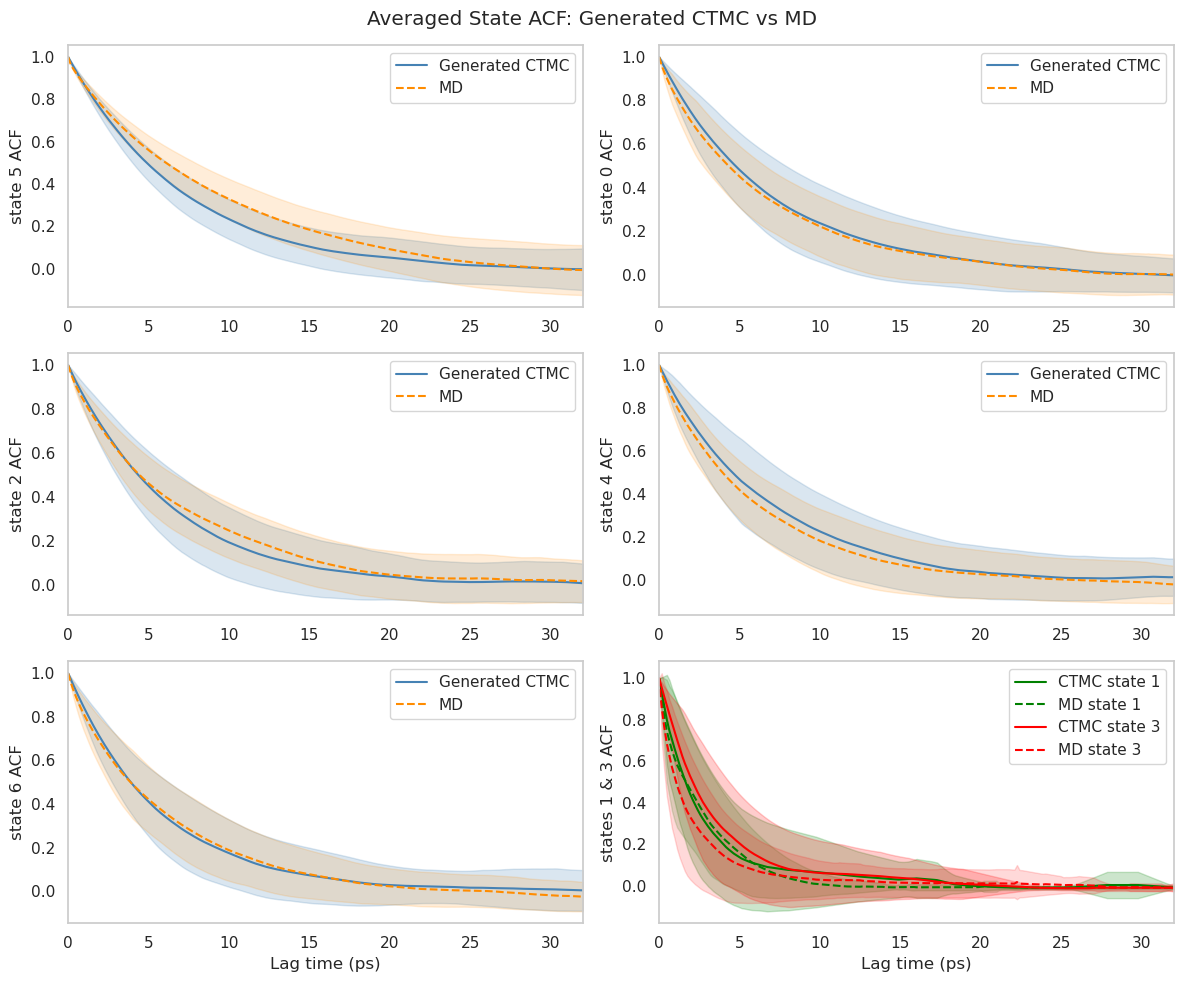

In [17]:
# Desired layout (3 rows x 2 cols):
# [5, 0]
# [2, 4]
# [6, (1 & 3 together)]

lags = np.arange(Klags + 1) * dt_grid

fig, axes = plt.subplots(3, 2, figsize=(12, 10))
axes = axes.flatten()

# Mapping states to subplot positions
state_positions = [5, 0, 2, 4, 6]

for idx, s in enumerate(state_positions):
    ax = axes[idx]

    # Simulation ACF
    ax.plot(lags, sim_acf_mean[s], color='steelblue', label='Generated CTMC')
    ax.fill_between(lags,
                    sim_acf_mean[s] - sim_acf_std[s],
                    sim_acf_mean[s] + sim_acf_std[s],
                    alpha=0.2, color='steelblue')

    # MD ACF overlay
    if have_md_acf:
        ax.plot(lags, md_acf_mean[s], color='darkorange', linestyle='--', label='MD')
        ax.fill_between(lags,
                        md_acf_mean[s] - md_acf_std[s],
                        md_acf_mean[s] + md_acf_std[s],
                        alpha=0.15, color='darkorange')

    ax.set_ylabel(f'state {s} ACF')
    ax.set_xlim(0, lags[-1])
    ax.grid(False)
    ax.legend()

# --- Bottom-right subplot: states 1 and 3 together ---
ax = axes[5]

for s, color in zip([1, 3], ['green', 'red']):
    ax.plot(lags, sim_acf_mean[s], label=f'CTMC state {s}', color=color)
    ax.fill_between(lags,
                    sim_acf_mean[s] - sim_acf_std[s],
                    sim_acf_mean[s] + sim_acf_std[s],
                    alpha=0.2, color=color)

    if have_md_acf:
        ax.plot(lags, md_acf_mean[s],
                linestyle='--', color=color,
                label=f'MD state {s}')
        ax.fill_between(lags,
                        md_acf_mean[s] - md_acf_std[s],
                        md_acf_mean[s] + md_acf_std[s],
                        alpha=0.15, color=color)

ax.set_ylabel('states 1 & 3 ACF')
ax.set_xlim(0, lags[-1])
ax.grid(False)
ax.legend()

# Common labels
for ax in axes[-2:]:
    ax.set_xlabel('Lag time (ps)')

plt.suptitle('Averaged State ACF: Generated CTMC vs MD')
plt.tight_layout()
plt.show()

In [18]:
# Compute implied timescales from K_scaled vs K_md_combined
eigvals_model = np.sort(np.real(np.linalg.eigvals(K_scaled_vis)))[::-1]
eigvals_md = np.sort(np.real(np.linalg.eigvals(K_md_comb_vis)))[::-1]

# The slowest few timescales should match
timescales_model = -1.0 / eigvals_model[eigvals_model < -1e-12]
timescales_md = -1.0 / eigvals_md[eigvals_md < -1e-12]

print('Implied timescales (model vs combined MD):')
for i in range(min(10, len(timescales_model), len(timescales_md))):
    print(f'  Mode {i}: model = {timescales_model[i]:.3g}, MD_combined = {timescales_md[i]:.3g}')

Implied timescales (model vs combined MD):
  Mode 0: model = 6.48, MD_combined = 6.48
  Mode 1: model = 5.78, MD_combined = 6.39
  Mode 2: model = 5.39, MD_combined = 5.81
  Mode 3: model = 4.89, MD_combined = 5.48
  Mode 4: model = 3.04, MD_combined = 3.2
  Mode 5: model = 2.95, MD_combined = 2.74


In [19]:
# Cell 15 — Export PDB/CSV of simulated trajectories & save generators
# Export representative PDB frames for visualizing event-driven sim (one model per event)
if backend == 'mdtraj' and isinstance(mc_traj, md.Trajectory):
    mc_coords = mc_traj.xyz
    d_to_cent = cdist(feats_mc, centroids)
    rep_idx = np.argmin(d_to_cent, axis=0)
    centroid_coords = mc_coords[rep_idx]
    # write for sim_view run
    sim_view = int(PARAMS['sim_view_index'])
    sim_view = max(0, min(sim_view, len(sim_states_list)-1))
    states_for_write = sim_states_list[sim_view]
    n_models = min(len(states_for_write), PARAMS['max_models'])
    frames_to_write = np.empty((n_models, centroid_coords.shape[1], 3), dtype=float)
    for i in range(n_models):
        frames_to_write[i] = centroid_coords[int(states_for_write[i])]
    traj_out = md.Trajectory(frames_to_write, topology=mc_traj.top)
    out_pdb = os.path.join(PARAMS['outputs_dir'], f'ctmc_simulated_traj_run_{sim_view}.pdb')
    traj_out.save(out_pdb)
    logger.info(f'Wrote {out_pdb}')

# Save K and centroids
np.save(os.path.join(PARAMS['outputs_dir'], 'K_scaled.npy'), K_scaled)
np.save(os.path.join(PARAMS['outputs_dir'], 'centroids.npy'), centroids)
np.save(os.path.join(PARAMS['outputs_dir'], 'pi.npy'), pi)

# events CSV for first sim
out_csv = os.path.join(PARAMS['outputs_dir'], 'ctmc_events.csv')
import csv
with open(out_csv, 'w', newline='') as f:
    w = csv.writer(f)
    w.writerow(['time', 'state'])
    for t, s in zip(times, states_seq):
        w.writerow([t, int(s)])
logger.info(f'Wrote events to {out_csv}')

print('Done — Notebook execution finished. Outputs in', PARAMS['outputs_dir'])

INFO:ctmc_nb:Wrote pentane_ctmc_outputs/ctmc_simulated_traj_run_0.pdb
INFO:ctmc_nb:Wrote events to pentane_ctmc_outputs/ctmc_events.csv


Done — Notebook execution finished. Outputs in pentane_ctmc_outputs


Reference (full K_md_combined):
  Implied timescales (ps): [6.4845 6.3884 5.8084]
  Frobenius norm (off-diag): 0.41214

frac=0.020 | length=  1792.0 ps | n_trans=  173 | relFro=0.506 | corr=0.822 | MARE=0.723 | maxRelErr=4.565
frac=0.023 | length=  2050.7 ps | n_trans=  201 | relFro=0.502 | corr=0.830 | MARE=0.680 | maxRelErr=4.203
frac=0.026 | length=  2346.9 ps | n_trans=  212 | relFro=0.484 | corr=0.841 | MARE=0.653 | maxRelErr=3.871
frac=0.030 | length=  2685.9 ps | n_trans=  244 | relFro=0.469 | corr=0.851 | MARE=0.634 | maxRelErr=2.787
frac=0.034 | length=  3073.8 ps | n_trans=  288 | relFro=0.470 | corr=0.849 | MARE=0.600 | maxRelErr=1.933
frac=0.039 | length=  3517.8 ps | n_trans=  334 | relFro=0.314 | corr=0.938 | MARE=0.542 | maxRelErr=1.550
frac=0.045 | length=  4025.8 ps | n_trans=  387 | relFro=0.224 | corr=0.973 | MARE=0.487 | maxRelErr=1.225
frac=0.051 | length=  4607.2 ps | n_trans=  462 | relFro=0.250 | corr=0.962 | MARE=0.517 | maxRelErr=1.000
frac=0.059 | length=  52

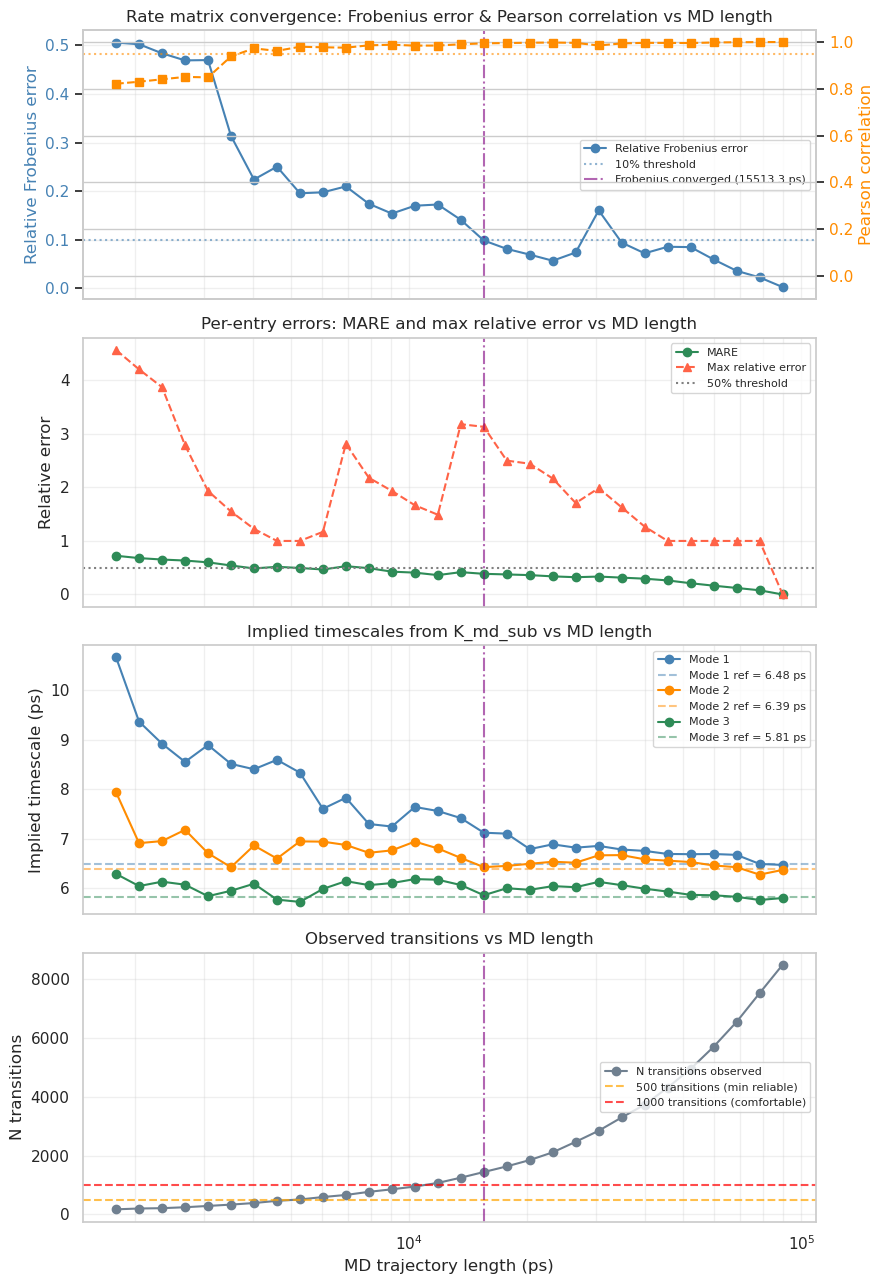


── MD Length Sensitivity Summary (rate matrix metrics) ──
 Length (ps)  N_trans   RelFro    Corr    MARE  MaxRelErr ts1(ps)  ts2(ps)  ts3(ps)
      1792.0      173    0.506   0.822   0.723      4.565       10.7       7.94       6.28
      2050.7      201    0.502   0.830   0.680      4.203       9.37       6.91       6.04
      2346.9      212    0.484   0.841   0.653      3.871       8.92       6.95       6.13
      2685.9      244    0.469   0.851   0.634      2.787       8.55       7.18       6.06
      3073.8      288    0.470   0.849   0.600      1.933       8.89        6.7       5.83
      3517.8      334    0.314   0.938   0.542      1.550       8.51       6.42       5.94
      4025.8      387    0.224   0.973   0.487      1.225        8.4       6.86       6.08
      4607.2      462    0.250   0.962   0.517      1.000       8.59       6.59       5.76
      5272.5      508    0.196   0.980   0.495      1.000       8.33       6.94       5.72
      6033.9      591    0.198   0.978

In [20]:
# Cell 16 — MD trajectory length sensitivity analysis (rate-matrix metrics)
# Tests how reliably the MD-estimated rate matrix converges as a function of
# trajectory length used. Does NOT use MFPT.
# Run AFTER Cell 10 (K_md_combined, K_scaled, labels_md available).
# Requires: labels_md, dt_md, N, K_md_combined, K_scaled

import numpy as np
import matplotlib.pyplot as plt


# ============================================================
# Helper: build K_md from a subset of MD labels
# ============================================================
def estimate_K_md_from_labels_subset(labels_sub, dt_md, N):
    """
    Estimate the raw MD generator from a contiguous prefix of label sequence.
    Returns (K_md_sub, n_transitions, time_in_state).
    """
    labels_sub = np.asarray(labels_sub, dtype=int)
    n = len(labels_sub)
    if n < 2:
        return None, 0, None

    changes = np.where(labels_sub[1:] != labels_sub[:-1])[0] + 1
    if len(changes) == 0:
        return None, 0, None

    prev_states = labels_sub[changes - 1]
    next_states  = labels_sub[changes]
    counts_sub   = np.zeros((N, N), dtype=float)
    for a, b in zip(prev_states, next_states):
        counts_sub[int(a), int(b)] += 1

    start_frames  = np.concatenate(([0], changes))
    end_frames    = np.concatenate((changes, [n]))
    dur_frames    = end_frames - start_frames
    states_block  = labels_sub[start_frames]

    time_in_state = np.zeros(N, dtype=float)
    for s, df in zip(states_block, dur_frames):
        time_in_state[int(s)] += df * dt_md

    K_md_sub = np.zeros((N, N), dtype=float)
    for i in range(N):
        if time_in_state[i] > 0:
            K_md_sub[i, :] = counts_sub[i, :] / time_in_state[i]
    for i in range(N):
        off_sum = np.sum(K_md_sub[i, :]) - K_md_sub[i, i]
        K_md_sub[i, i] = -off_sum

    return K_md_sub, int(len(changes)), time_in_state


# ============================================================
# Helper: implied timescales from a generator matrix
# ============================================================
def implied_timescales(Kmat, n_modes=3, tol=1e-10):
    """
    Returns the n_modes slowest implied timescales (-1/Re(lambda))
    excluding the zero eigenvalue.
    """
    eigs = np.linalg.eigvals(Kmat)
    real_parts = np.real(eigs)
    mask = real_parts < -tol
    if not np.any(mask):
        return np.full(n_modes, np.nan)
    ts = np.sort(-1.0 / real_parts[mask])[::-1]   # slowest first
    # pad with nan if fewer than n_modes found
    out = np.full(n_modes, np.nan)
    out[:min(n_modes, len(ts))] = ts[:n_modes]
    return out


# ============================================================
# Reference values from the full K_md_combined
# ============================================================
n_modes_to_track = min(3, N - 1)

mask_off      = ~np.eye(N, dtype=bool)
k_ref_offdiag = K_md_combined[mask_off]          # full MD off-diagonal entries
ts_ref        = implied_timescales(K_md_combined, n_modes=n_modes_to_track)

print("Reference (full K_md_combined):")
print(f"  Implied timescales (ps): {ts_ref}")
print(f"  Frobenius norm (off-diag): {np.linalg.norm(k_ref_offdiag):.5g}\n")


# ============================================================
# Sweep: fractions of the MD trajectory (log-spaced)
# ============================================================
fracs           = np.logspace(np.log10(0.02), np.log10(1.0), 30)

# use the same concatenated labels that built K_md_combined in Cell 14
if 'md_labels_list' not in dir() or len(md_labels_list) == 0:
    raise RuntimeError('md_labels_list not found — run Cell 14 first, '
                       'or check that PARAMS["md_dir"] is set correctly.')
labels_md_all   = np.concatenate(md_labels_list)
n_total_frames  = len(labels_md_all)
results         = []

for frac in fracs:
    n_frames_sub  = max(10, int(frac * n_total_frames))
    labels_sub    = labels_md_all[:n_frames_sub]
    traj_length_ps = n_frames_sub * dt_md

    K_md_sub, n_trans, time_in_state_sub = estimate_K_md_from_labels_subset(
        labels_sub, dt_md, N
    )

    if K_md_sub is None:
        results.append({
            'frac': frac, 'traj_length_ps': traj_length_ps,
            'n_transitions': 0,
            'rel_fro': np.nan, 'corr': np.nan,
            'mare': np.nan, 'max_rel_err': np.nan,
            'timescales': np.full(n_modes_to_track, np.nan),
            'min_state_visits': 0,
        })
        continue

    # ---- Frobenius relative error (off-diagonal only) ----
    k_sub_flat = K_md_sub[mask_off]
    fro_diff   = np.linalg.norm(k_sub_flat - k_ref_offdiag)
    fro_ref    = np.linalg.norm(k_ref_offdiag)
    rel_fro    = fro_diff / (fro_ref + 1e-300)

    # ---- Pearson correlation (off-diagonal) ----
    if k_sub_flat.size > 2:
        corr = float(np.corrcoef(k_sub_flat, k_ref_offdiag)[0, 1])
    else:
        corr = np.nan

    # ---- MARE (where reference is nonzero) ----
    nonzero_ref = np.abs(k_ref_offdiag) > 1e-12
    if np.any(nonzero_ref):
        abs_rel_errs = np.abs(
            (k_sub_flat[nonzero_ref] - k_ref_offdiag[nonzero_ref])
            / (k_ref_offdiag[nonzero_ref] + 1e-300)
        )
        mare        = float(np.mean(abs_rel_errs))
        max_rel_err = float(np.max(abs_rel_errs))
    else:
        mare = max_rel_err = np.nan

    # ---- Implied timescales ----
    ts_sub = implied_timescales(K_md_sub, n_modes=n_modes_to_track)

    # ---- Minimum visits across states (data coverage) ----
    min_visits = int(np.min(time_in_state_sub / dt_md)) if time_in_state_sub is not None else 0

    results.append({
        'frac': frac,
        'traj_length_ps': traj_length_ps,
        'n_transitions': n_trans,
        'rel_fro': rel_fro,
        'corr': corr,
        'mare': mare,
        'max_rel_err': max_rel_err,
        'timescales': ts_sub,
        'min_state_visits': min_visits,
    })

    print(f"frac={frac:.3f} | length={traj_length_ps:8.1f} ps | "
          f"n_trans={n_trans:5d} | relFro={rel_fro:.3f} | "
          f"corr={corr:.3f} | MARE={mare:.3f} | maxRelErr={max_rel_err:.3f}")


# ============================================================
# Unpack results for plotting
# ============================================================
lengths      = np.array([r['traj_length_ps']   for r in results])
rel_fros     = np.array([r['rel_fro']           for r in results])
corrs        = np.array([r['corr']              for r in results])
mares        = np.array([r['mare']              for r in results])
max_rel_errs = np.array([r['max_rel_err']       for r in results])
n_trans_arr  = np.array([r['n_transitions']     for r in results])
timescales   = np.vstack([r['timescales']        for r in results])   # (n_fracs, n_modes)


# ============================================================
# Figure: 4 panels
# ============================================================
fig, axes = plt.subplots(4, 1, figsize=(9, 13), sharex=True)
colors = ['steelblue', 'darkorange', 'seagreen']

# ---- Panel 1: Frobenius + Pearson ----
ax = axes[0]
ax.semilogx(lengths, rel_fros, 'o-', color='steelblue', label='Relative Frobenius error')
ax.axhline(0.1, color='steelblue', linestyle=':', alpha=0.6, label='10% threshold')
ax2 = ax.twinx()
ax2.semilogx(lengths, corrs, 's--', color='darkorange', label='Pearson corr (off-diag)')
ax2.axhline(0.95, color='darkorange', linestyle=':', alpha=0.6, label='r=0.95 threshold')
ax2.set_ylabel('Pearson correlation', color='darkorange')
ax2.tick_params(axis='y', labelcolor='darkorange')
ax2.set_ylim([-0.1, 1.05])
ax.set_ylabel('Relative Frobenius error', color='steelblue')
ax.tick_params(axis='y', labelcolor='steelblue')
ax.set_title('Rate matrix convergence: Frobenius error & Pearson correlation vs MD length')
lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, labels1 + labels2, fontsize=8)
ax.grid(True, which='both', alpha=0.3)

# ---- Panel 2: MARE + max relative error ----
ax = axes[1]
ax.semilogx(lengths, mares,        'o-',  color='seagreen',    label='MARE')
ax.semilogx(lengths, max_rel_errs, '^--', color='tomato',      label='Max relative error')
ax.axhline(0.5, color='gray', linestyle=':', label='50% threshold')
ax.set_ylabel('Relative error')
ax.set_title('Per-entry errors: MARE and max relative error vs MD length')
ax.legend(fontsize=8)
ax.grid(True, which='both', alpha=0.3)

# ---- Panel 3: Implied timescales ----
ax = axes[2]
mode_colors = ['steelblue', 'darkorange', 'seagreen']
for m in range(n_modes_to_track):
    ax.semilogx(lengths, timescales[:, m], 'o-',
                color=mode_colors[m % len(mode_colors)],
                label=f'Mode {m+1}')
    ax.axhline(ts_ref[m], color=mode_colors[m % len(mode_colors)],
               linestyle='--', alpha=0.5,
               label=f'Mode {m+1} ref = {ts_ref[m]:.3g} ps')
ax.set_ylabel('Implied timescale (ps)')
ax.set_title('Implied timescales from K_md_sub vs MD length')
ax.legend(fontsize=8)
ax.grid(True, which='both', alpha=0.3)

# ---- Panel 4: Number of observed transitions ----
ax = axes[3]
ax.semilogx(lengths, n_trans_arr, 'o-', color='slategray', label='N transitions observed')
ax.axhline(500,  color='orange', linestyle='--', alpha=0.7, label='500 transitions (min reliable)')
ax.axhline(1000, color='red',    linestyle='--', alpha=0.7, label='1000 transitions (comfortable)')
ax.set_ylabel('N transitions')
ax.set_xlabel('MD trajectory length (ps)')
ax.set_title('Observed transitions vs MD length')
ax.legend(fontsize=8, loc='center right')
ax.grid(True, which='both', alpha=0.3)

# Mark convergence point on all panels (first length where rel_fro < 0.1 for 3 consecutive)
converged_length = None
converged_idx    = None
for i in range(len(results) - 2):
    if all(results[j]['rel_fro'] < 0.1 for j in [i, i+1, i+2]
           if not np.isnan(results[j]['rel_fro'])):
        converged_length = results[i]['traj_length_ps']
        converged_idx    = i
        break

if converged_length is not None:
    for ax in axes:
        ax.axvline(converged_length, color='purple', linestyle='-.',
                   alpha=0.6, label=f'Frobenius converged ({converged_length:.1f} ps)')
    axes[0].legend(fontsize=8, loc='center right')

plt.tight_layout()
plt.savefig(os.path.join(PARAMS['outputs_dir'], 'md_length_sensitivity_Kmetrics.png'),
            dpi=150, bbox_inches='tight')
plt.show()


# ============================================================
# Summary table
# ============================================================
print("\n── MD Length Sensitivity Summary (rate matrix metrics) ──")
print(f"{'Length (ps)':>12} {'N_trans':>8} {'RelFro':>8} "
      f"{'Corr':>7} {'MARE':>7} {'MaxRelErr':>10} "
      + "  ".join([f'ts{m+1}(ps)' for m in range(n_modes_to_track)]))
for r in results:
    ts_str = "  ".join([f"{r['timescales'][m]:>9.3g}" for m in range(n_modes_to_track)])
    print(f"{r['traj_length_ps']:>12.1f} {r['n_transitions']:>8} "
          f"{r['rel_fro']:>8.3f} {r['corr']:>7.3f} "
          f"{r['mare']:>7.3f} {r['max_rel_err']:>10.3f}  {ts_str}")

if converged_length is not None:
    cr = results[converged_idx]
    print(f"\nRate matrix converges (RelFro < 10% for 3 consecutive points) at:")
    print(f"  MD length        = {converged_length:.1f} ps")
    print(f"  N transitions    = {cr['n_transitions']}")
    print(f"  MARE at that point = {cr['mare']:.3f}")
    print(f"  Pearson corr       = {cr['corr']:.3f}")
    full_length = lengths[-1]
    print(f"  Full MD length   = {full_length:.1f} ps")
    print(f"  Compression factor = {full_length / converged_length:.1f}x")
else:
    print("\nRate matrix did not converge within the tested MD length range.")
    print("Consider using longer MD trajectories or fewer clusters.")